## Biweekly 20.01

In [64]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats
from scipy.stats import chi2_contingency
from typing import Callable

def _resolve_project_root() -> Path:
    """locate project root containing config.py."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            print(candidate)
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')


PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import GENE_PATHS, SOURCE_PALETTE, VARIANT_PATHS

/Users/markus/in-silico-vg-analysis


In [65]:
CLINGEN_VAR = VARIANT_PATHS['clingen']
BG_VAR = VARIANT_PATHS['background']
BG_NULL_VAR = VARIANT_PATHS['background_null']
CLINGEN_NULL_VAR = VARIANT_PATHS['clingen_null']

CLINGEN_GENE = GENE_PATHS['clingen']
BG_GENE = GENE_PATHS['background']
BG_NULL_GENE = GENE_PATHS['background_null']
CLINGEN_NULL_GENE = GENE_PATHS['clingen_null']

PATHS = {
    'background': BG_GENE,
    'background_null': BG_NULL_GENE,
    'clingen': CLINGEN_GENE,
    'clingen_null': CLINGEN_NULL_GENE,
}

df = pl.read_parquet(CLINGEN_NULL_GENE)
print(df.columns)
print(df.head())

# TODO: add dedublication logic

def _dedup_scores_by_variant(
    path: str | Path, label: str, columns: list[str] | None = None
) -> pl.DataFrame:
    """dedup track-level scores to one row per variant (max abs score).

    args:
        path (str | Path): variant file path.
        label (str): source label to attach.
        columns (list[str] | None): extra columns to retain after dedup.

    returns:
        pl.DataFrame: deduped variants with selected columns.

    raises:
        FileNotFoundError: when the file is missing.
        ValueError: when required columns are missing.
    """
    columns = [] if columns is None else columns

    file_path = Path(path)
    if not file_path.exists():
        raise FileNotFoundError(f'missing variant file: {file_path}')

    schema_cols = pl.read_parquet(file_path, n_rows=0).columns
    if 'raw_score' in schema_cols:
        score_col = 'raw_score'
    elif 'score' in schema_cols:
        score_col = 'score'
    else:
        raise ValueError(f'missing raw_score/score column in {file_path}')

    group_cols = [
        c for c in ['variant_id', 'CHROM', 'POS', 'REF', 'ALT', 'gene_id'] if c in schema_cols
    ]
    if not group_cols:
        raise ValueError('no variant identifier columns found')

    missing = [c for c in columns if c not in schema_cols]
    if missing:
        raise ValueError(f'missing columns in {file_path}: {missing}')

    select_cols = list(dict.fromkeys([score_col, *group_cols, *columns]))

    deduped = (
        pl.scan_parquet(file_path)
        .select(select_cols)
        .filter(pl.col(score_col).is_not_null())
        .with_columns(pl.col(score_col).abs().alias('_abs_score'))
        .sort(group_cols + ['_abs_score'], descending=[False] * len(group_cols) + [True])
        .unique(subset=group_cols, keep='first')
        .with_columns(
            pl.col(score_col).alias('raw_score'),
            pl.col(score_col).abs().alias('abs_score'),
            pl.lit(label).alias('source'),
        )
        .drop('_abs_score')
        .select(
            list(dict.fromkeys([*group_cols, *columns, 'raw_score', 'abs_score', 'source']))
        )
        .collect()
    )

    return deduped



def _load_variant_table(path: str | Path, label: str, columns: list[str] | None) -> pl.DataFrame:
    """load selected columns from a variant file and tag source after dedup.

    args:
        path (str | Path): variant file path.
        label (str): source label to attach.
        columns (list[str] | None): columns to load from the file.

    returns:
        pl.DataFrame: deduped subset with source column attached.

    raises:
        FileNotFoundError: when the file is missing.
        ValueError: when the file is empty or missing columns.
    """
    columns = [] if columns is None else columns

    table = _dedup_scores_by_variant(path=path, label=label, columns=columns)
    if table.is_empty():
        raise ValueError(f'no rows in variant file: {Path(path)}')

    return table


def _load_scores(path: str | Path, label: str) -> pl.DataFrame:
    """load deduped scores with source tag for downstream analysis."""
    return _load_variant_table(path=path, label=label, columns=None)

['gene_id', 'n_variants', 'vg_predicted', 'vg_predicted_perm', 'n_variants_perm', 'sum_sq_raw_score', 'mean_raw_score', 'mean_abs_effect', 'median_abs_effect', 'std_abs_effect', 'min_abs_effect', 'max_abs_effect', 'skewness_effect', 'q90_abs_effect', 'min_variant_id', 'min_variant_score', 'max_variant_id', 'max_variant_score', 'mean_dist_to_tss', 'median_dist_to_tss', 'min_dist_to_tss', 'max_dist_to_tss', 'n_high_impact_gt05', 'n_high_impact_gt1', 'mean_abs_promoter', 'n_variants_promoter', 'mean_abs_up2kb', 'n_variants_up2kb', 'mean_abs_up10kb', 'n_variants_up10kb', 'mean_abs_up100kb', 'n_variants_up100kb', 'mean_abs_down2kb', 'n_variants_down2kb', 'mean_abs_gene_body', 'n_variants_gene_body', 'gene_symbol', 'gene_type', 'chrom', 'genomic_length', 'exonic_length', 'coding_length', 'intronic_length', 'utr_length', 'utr5_length', 'mane_transcript_id', 'is_mane', 'tpm_muscle', 'ncRVIS', 'loeuf_score', 'ncGERP', 'RVIS_score', 'ncCADD', 'pHaplo', 'pTriplo', 'Episcore', 'pLI', 'median_tpm',

# What's new this week

1. We will change the naming for NULL sets to synthetic (SYNTH) and specify that our ClinGen dataset is Haploinsufficent. Therefore the new naming from here on will be. The reason to do this is because NULL is too vauge description for our usecase. 

- ClinGen_HI_Gnomad 
- ClinGen_HI_Synth
- Background_Gnomad
- Background_Sytnh

2. We will introduce VG scores to our Synthetic datasets. We do this by  comparing observed per-gene genetic variance to a permutation-based null distribution generated by randomly reassigning allele frequencies (AFs) from a global pool of observed variants keeping the distingtion between ClinGen_HI and Background datasets. Our new variants file have now new column vg_predicted_perm

3. For our gene level analysis we divide genes by different categories based on if the gene is singleton or doubleton or tripleton. We make extra annotations to our vairant level files on from AC values from intermediate variant files and calculate with aggregator module fractions of how many variants are affecting the gene level absolute score.

4. We calculate the gene-metrics correlations between whole groups, not just feature based

In [66]:
# 0. Gene 

# 1. Permutation VG scores violin plot

In [67]:
TARGET_METRICS_GNOMAD = ['vg_predicted']
TARGET_METRICS_SYNTHETIC = ['vg_predicted_perm']

def _load_vg_metrics_gnomad() -> pd.DataFrame:
    frames: list[pl.DataFrame] = []
    for dataset, path in {'clingen': CLINGEN_GENE, 'background': BG_GENE}.items():
        frame = pl.read_parquet(path)
        missing = [col for col in TARGET_METRICS_GNOMAD if col not in frame.columns]
        if missing:
            raise ValueError(f'missing columns {missing} in {dataset} gene file')
        subset = frame.select(list(TARGET_METRICS_GNOMAD.keys())).with_columns(
            pl.lit(dataset).alias('dataset')
        )
        frames.append(subset)
    return pl.concat(frames, how='vertical').to_pandas()

    
def _load_vg_metrics_synthetic() -> pd.DataFrame:
    frames: list[pl.DataFrame] = []
    for dataset, path in {'clingen': CLINGEN_GENE, 'background': BG_GENE}.items():
        frame = pl.read_parquet(path)
        missing = [col for col in TARGET_METRICS_SYNTHETIC if col not in frame.columns]
        if missing:
            raise ValueError(f'missing columns {missing} in {dataset} gene file')
        subset = frame.select(list(TARGET_METRICS_SYNTHETIC.keys())).with_columns(
            pl.lit(dataset).alias('dataset')
        )
        frames.append(subset)
    return pl.concat(frames, how='vertical').to_pandas()


def _compute_vg_perm_values(length_long: pd.DataFrame) -> dict[str, float]:
    """compute welch p-values on vg_scores"""
    p_values: dict[str, float] = {}
    for metric, label in length_cols.items():
        subset = length_long[length_long['metric'] == metric]
        clingen_vals = subset.loc[subset['dataset'] == 'clingen', 'length_log10'].dropna()
        background_vals = subset.loc[subset['dataset'] == 'background', 'length_log10'].dropna()
        if clingen_vals.empty or background_vals.empty:
            raise ValueError(f'no data for {metric}')
        _, p_value = stats.ttest_ind(clingen_vals, background_vals, equal_var=False)
        p_values[label] = float(p_value)
    return p_values



/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:84: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if 'gene_id' not in df.columns and 'gene_tag' in df.columns:
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:84: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if 'gene_id' not in df.columns and 'gene_tag' in df.columns:
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:84: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().na

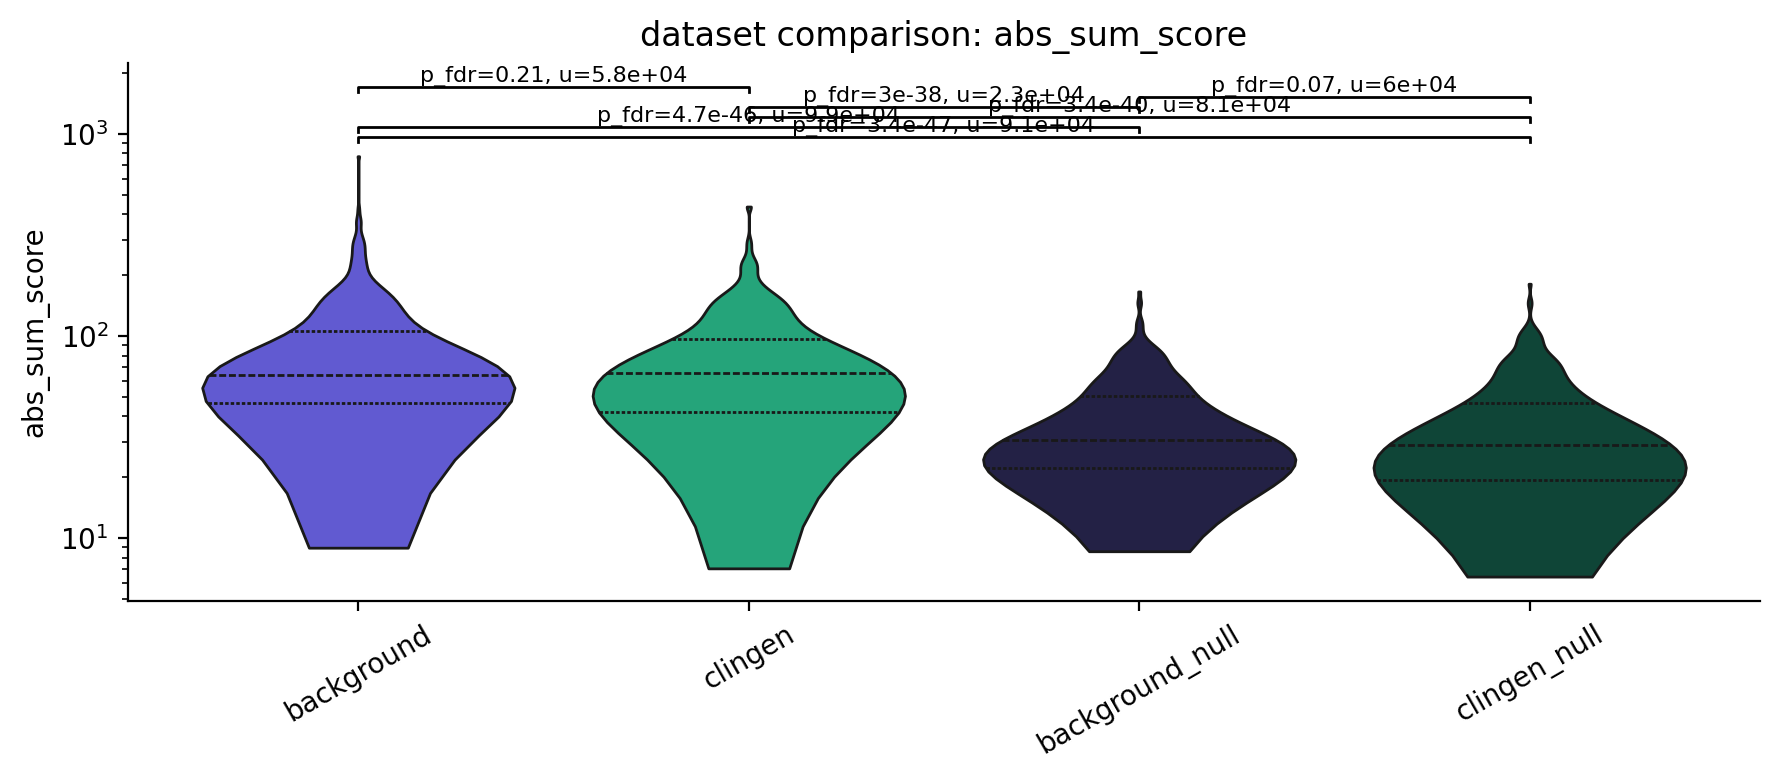

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:412: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


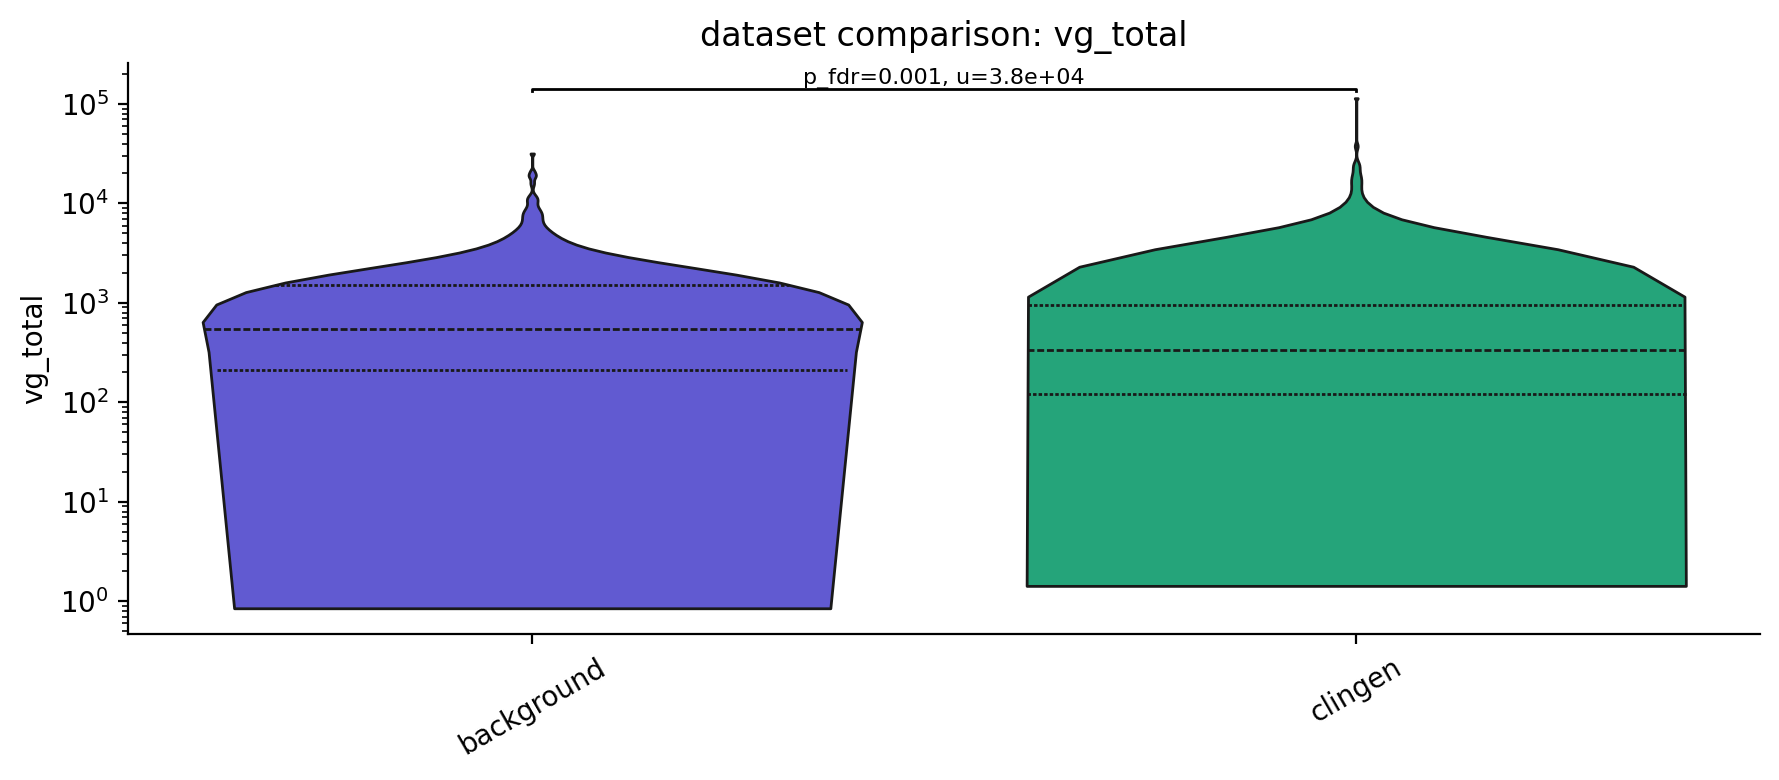

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:412: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


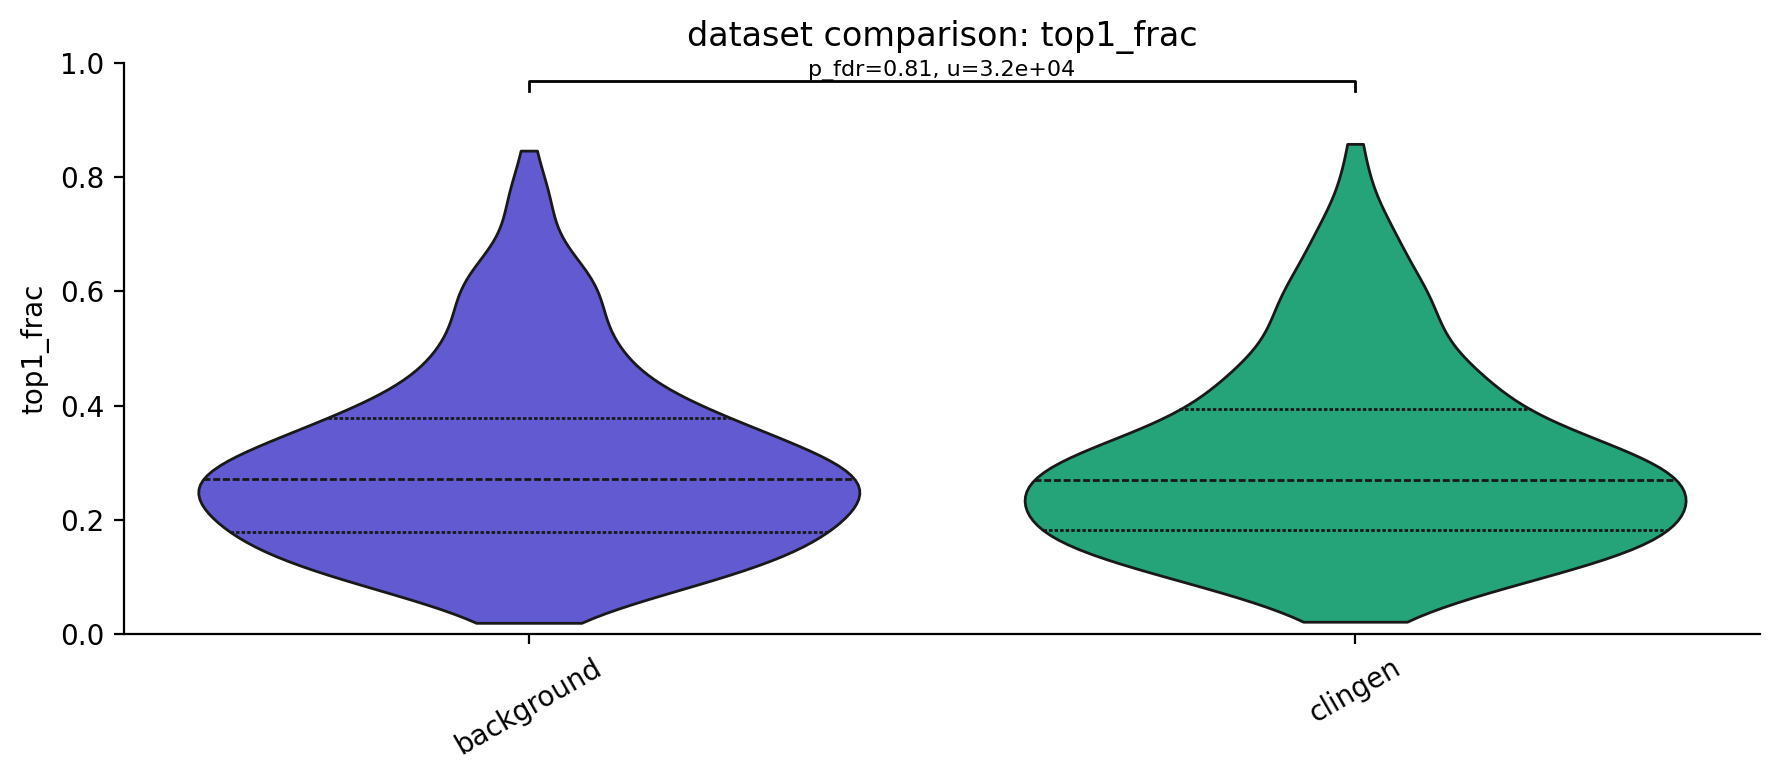

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:412: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


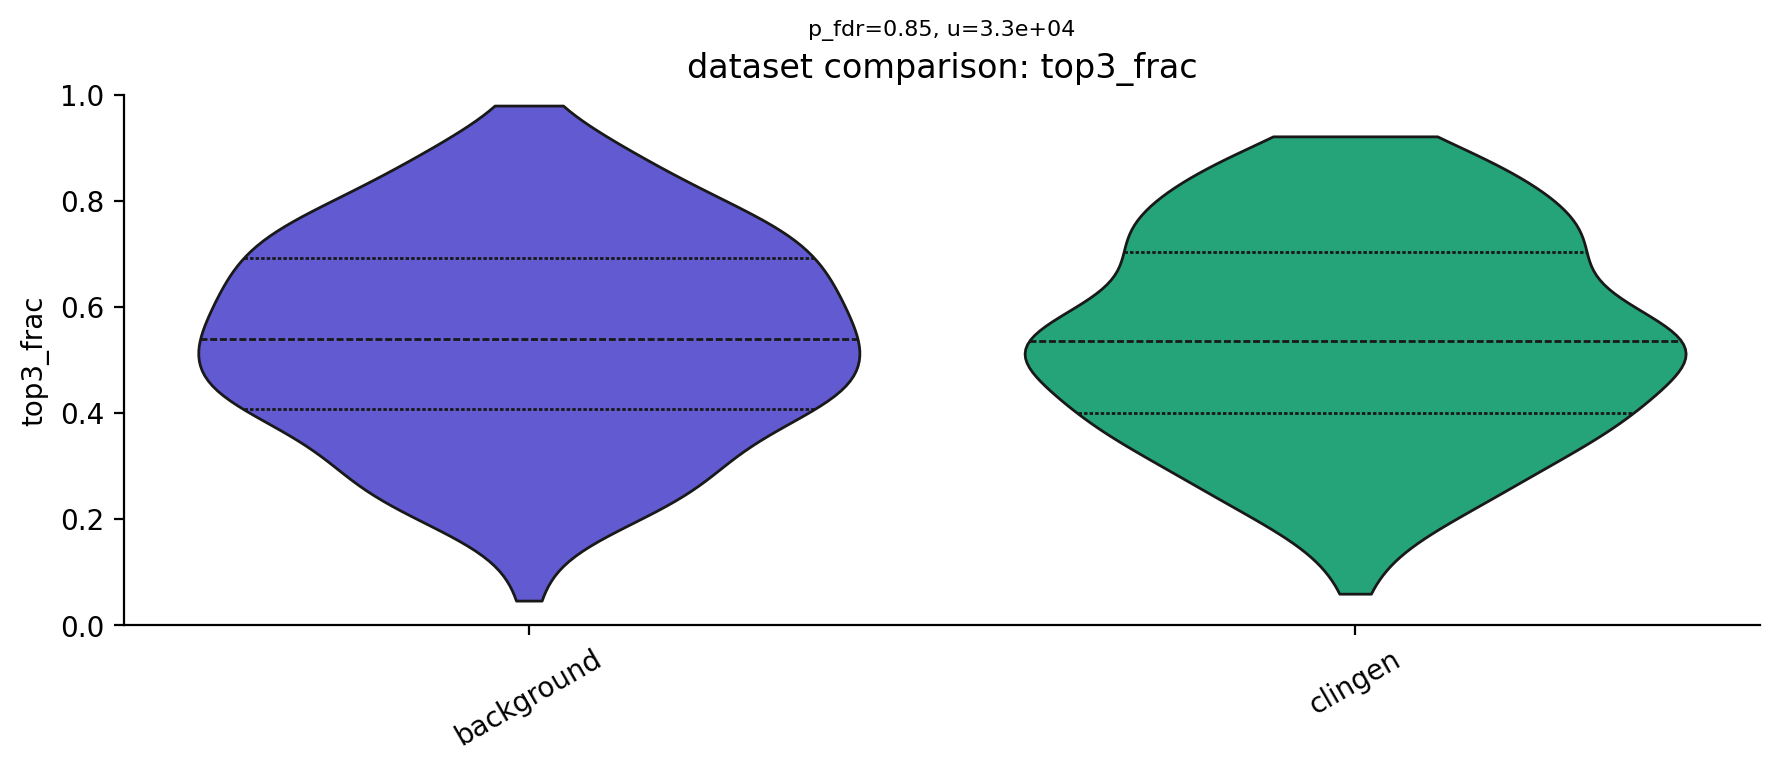

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:412: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


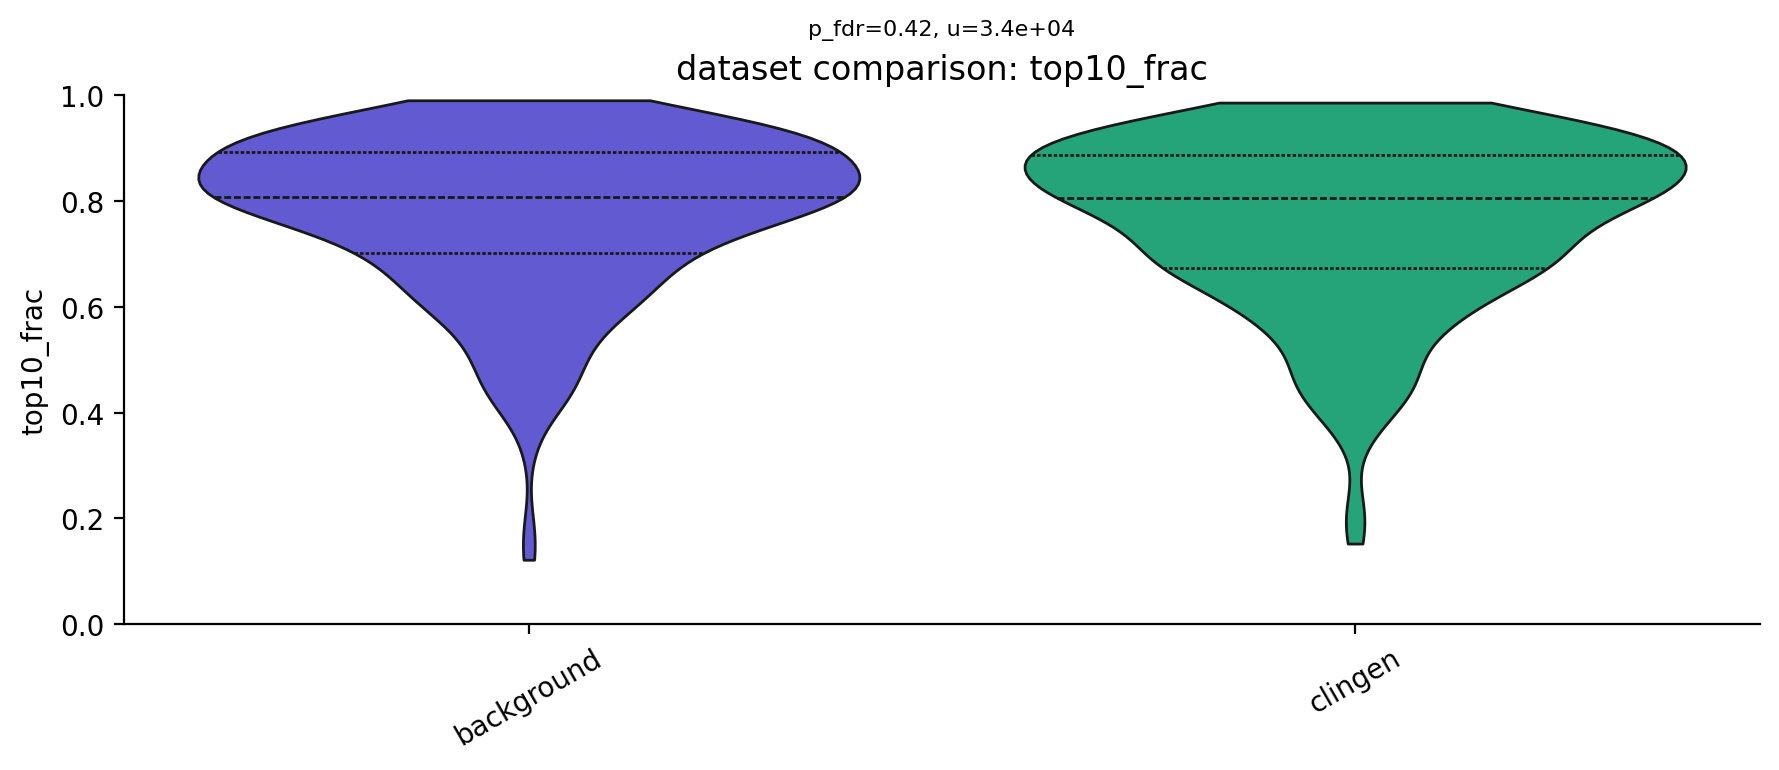

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:412: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


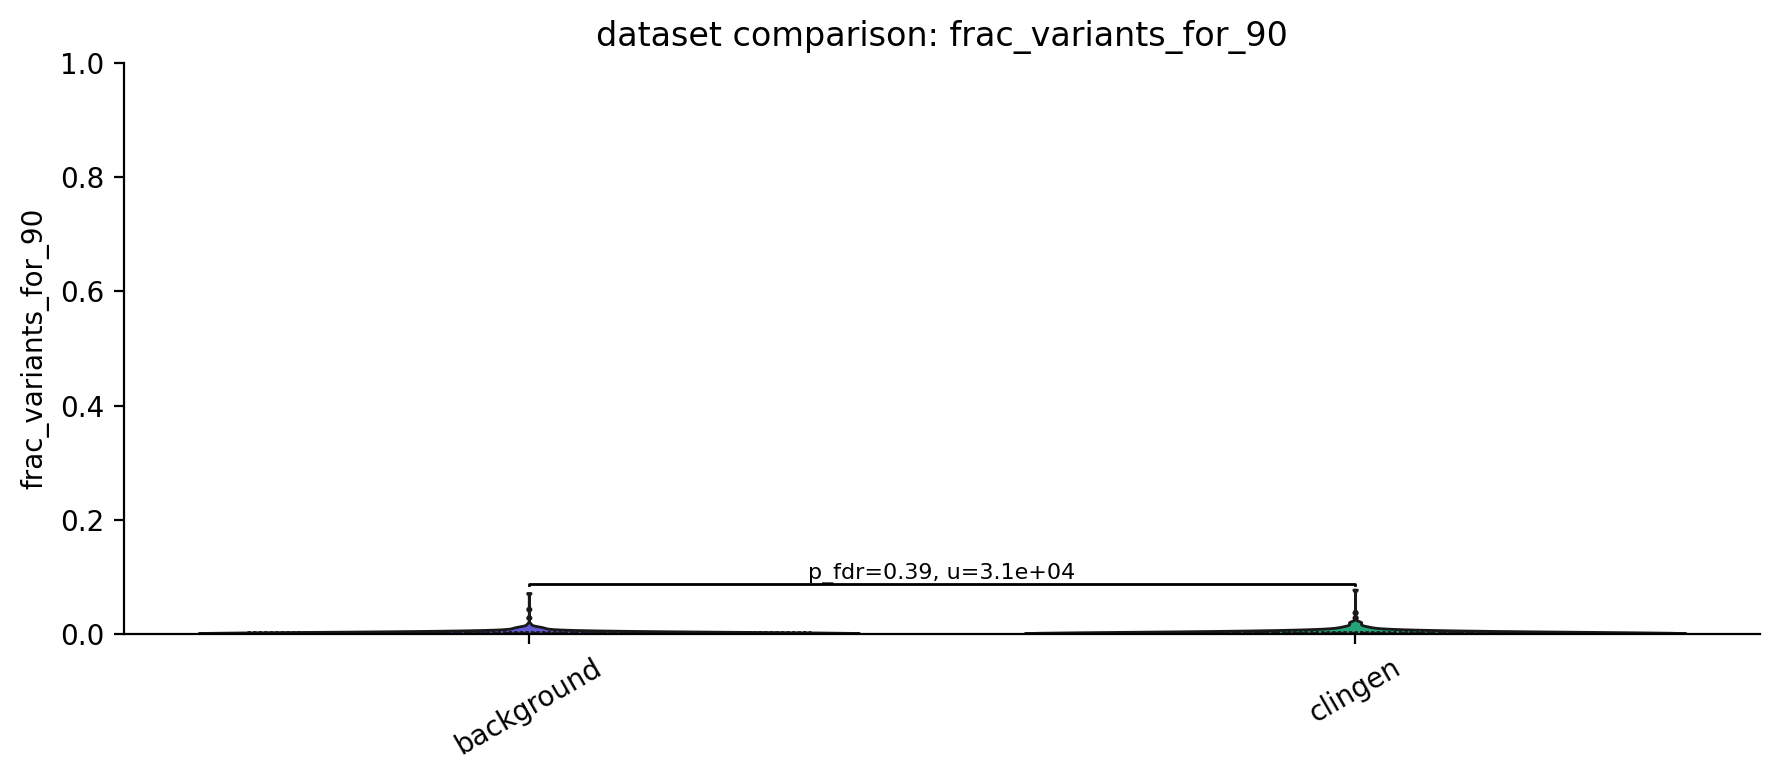

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:412: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


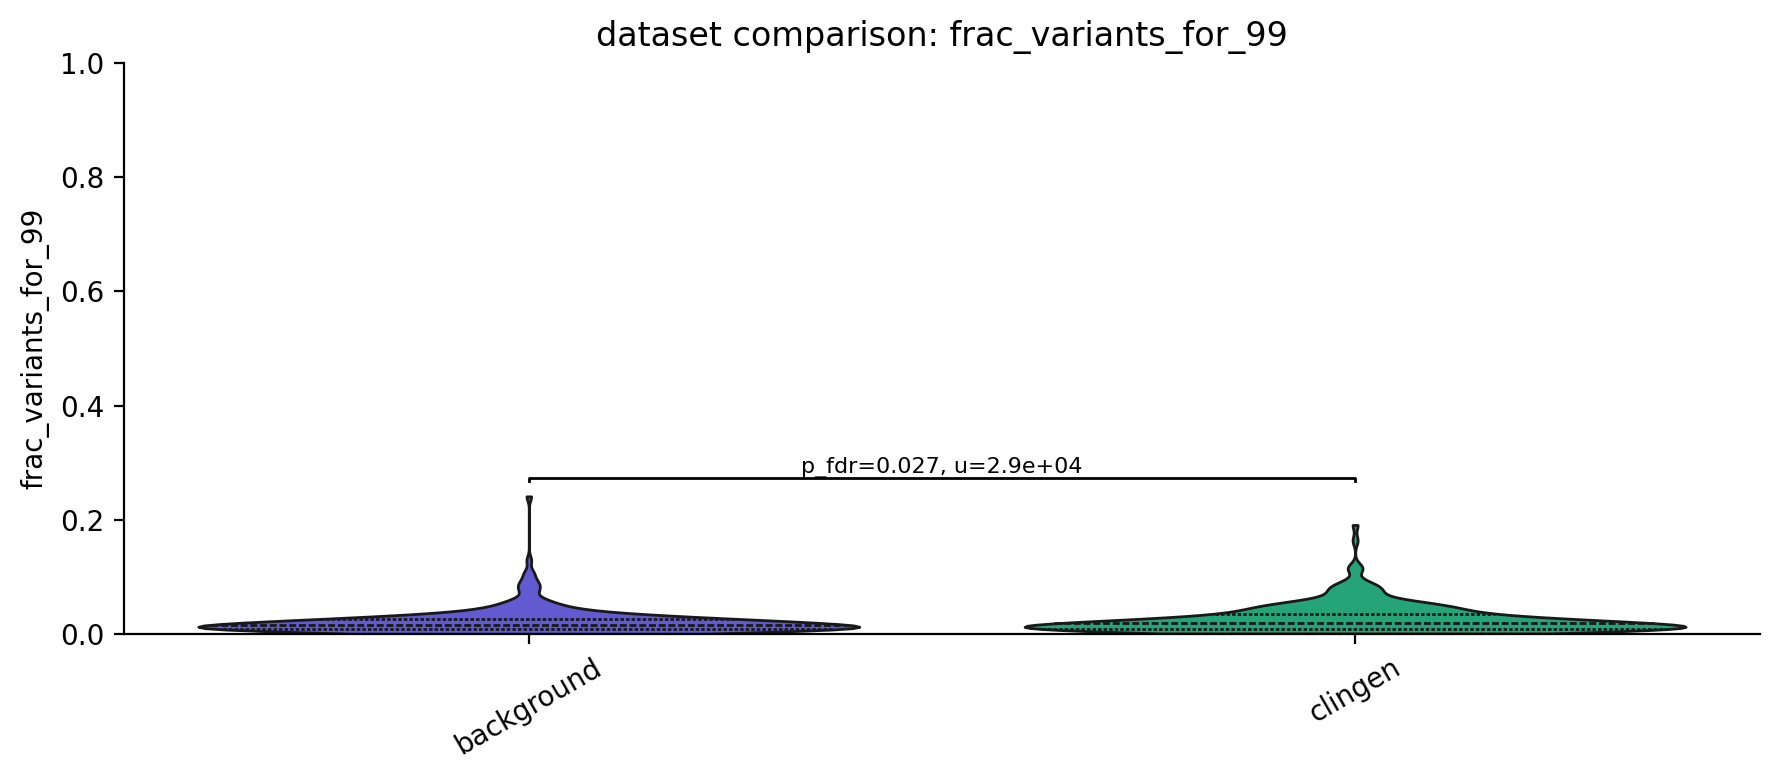

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:291: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g for g, sub in df.groupby(group_col) if len(sub) >= min_n]
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0

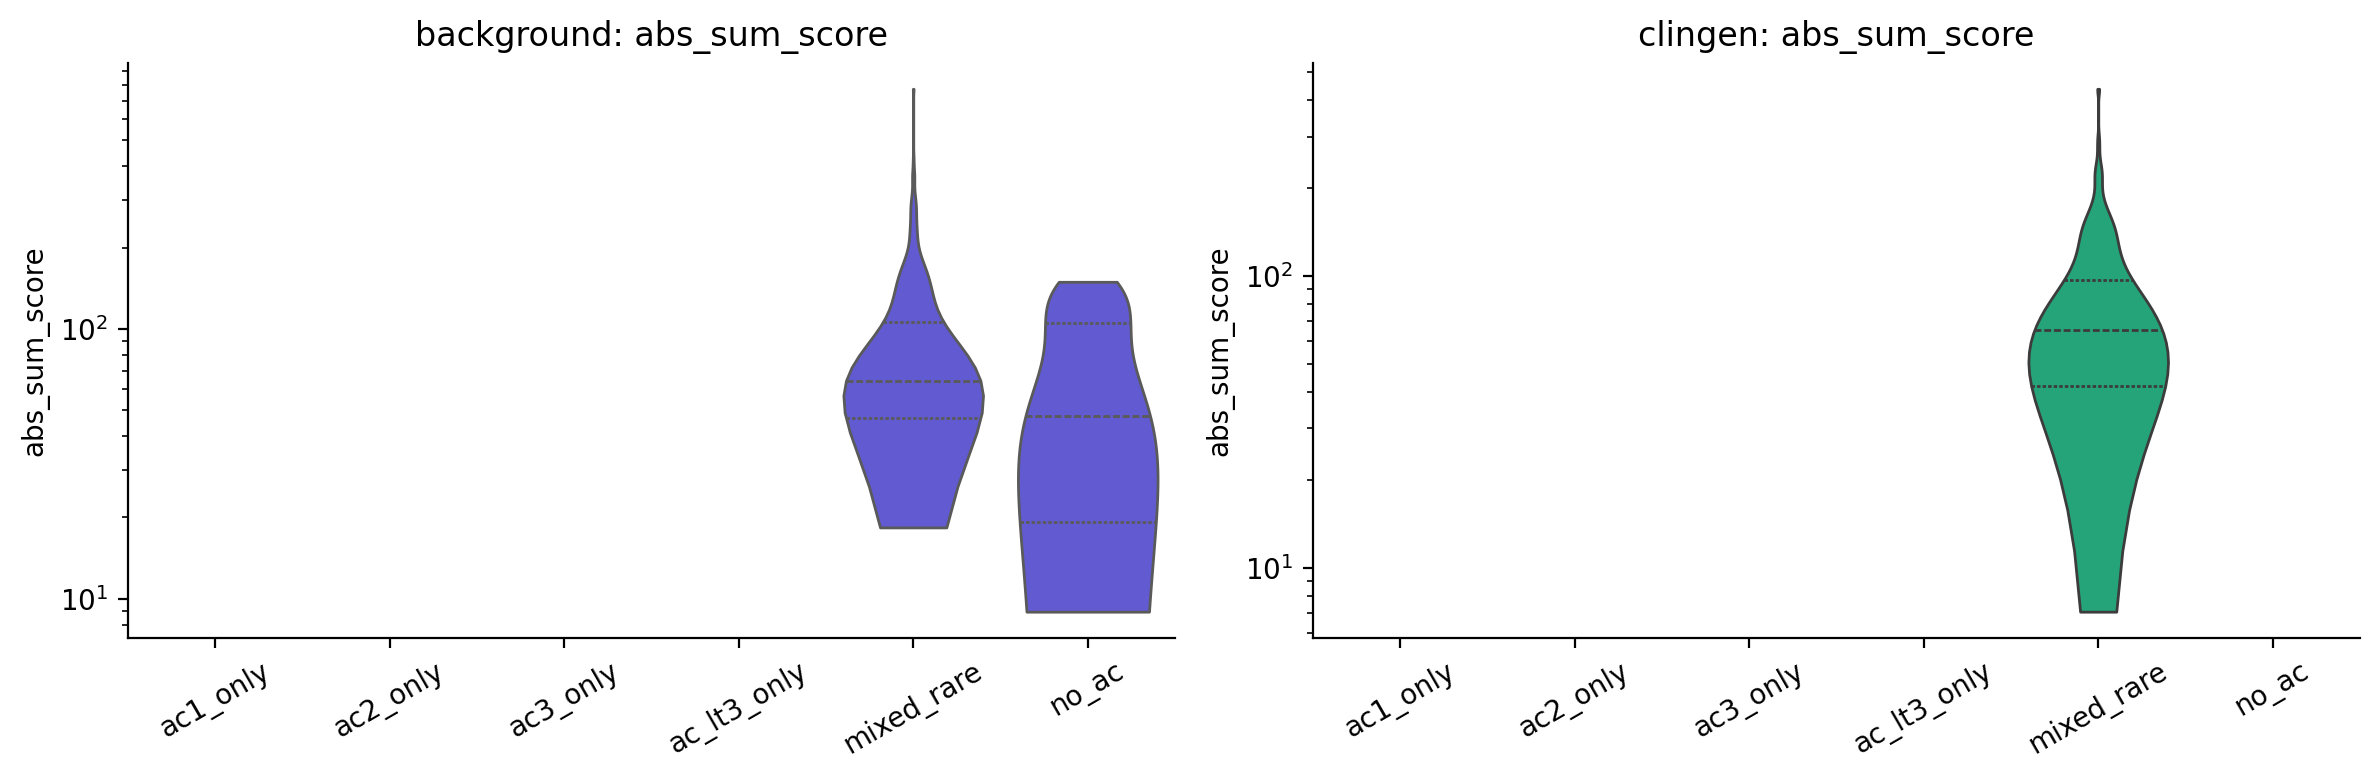

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:291: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g for g, sub in df.groupby(group_col) if len(sub) >= min_n]
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0

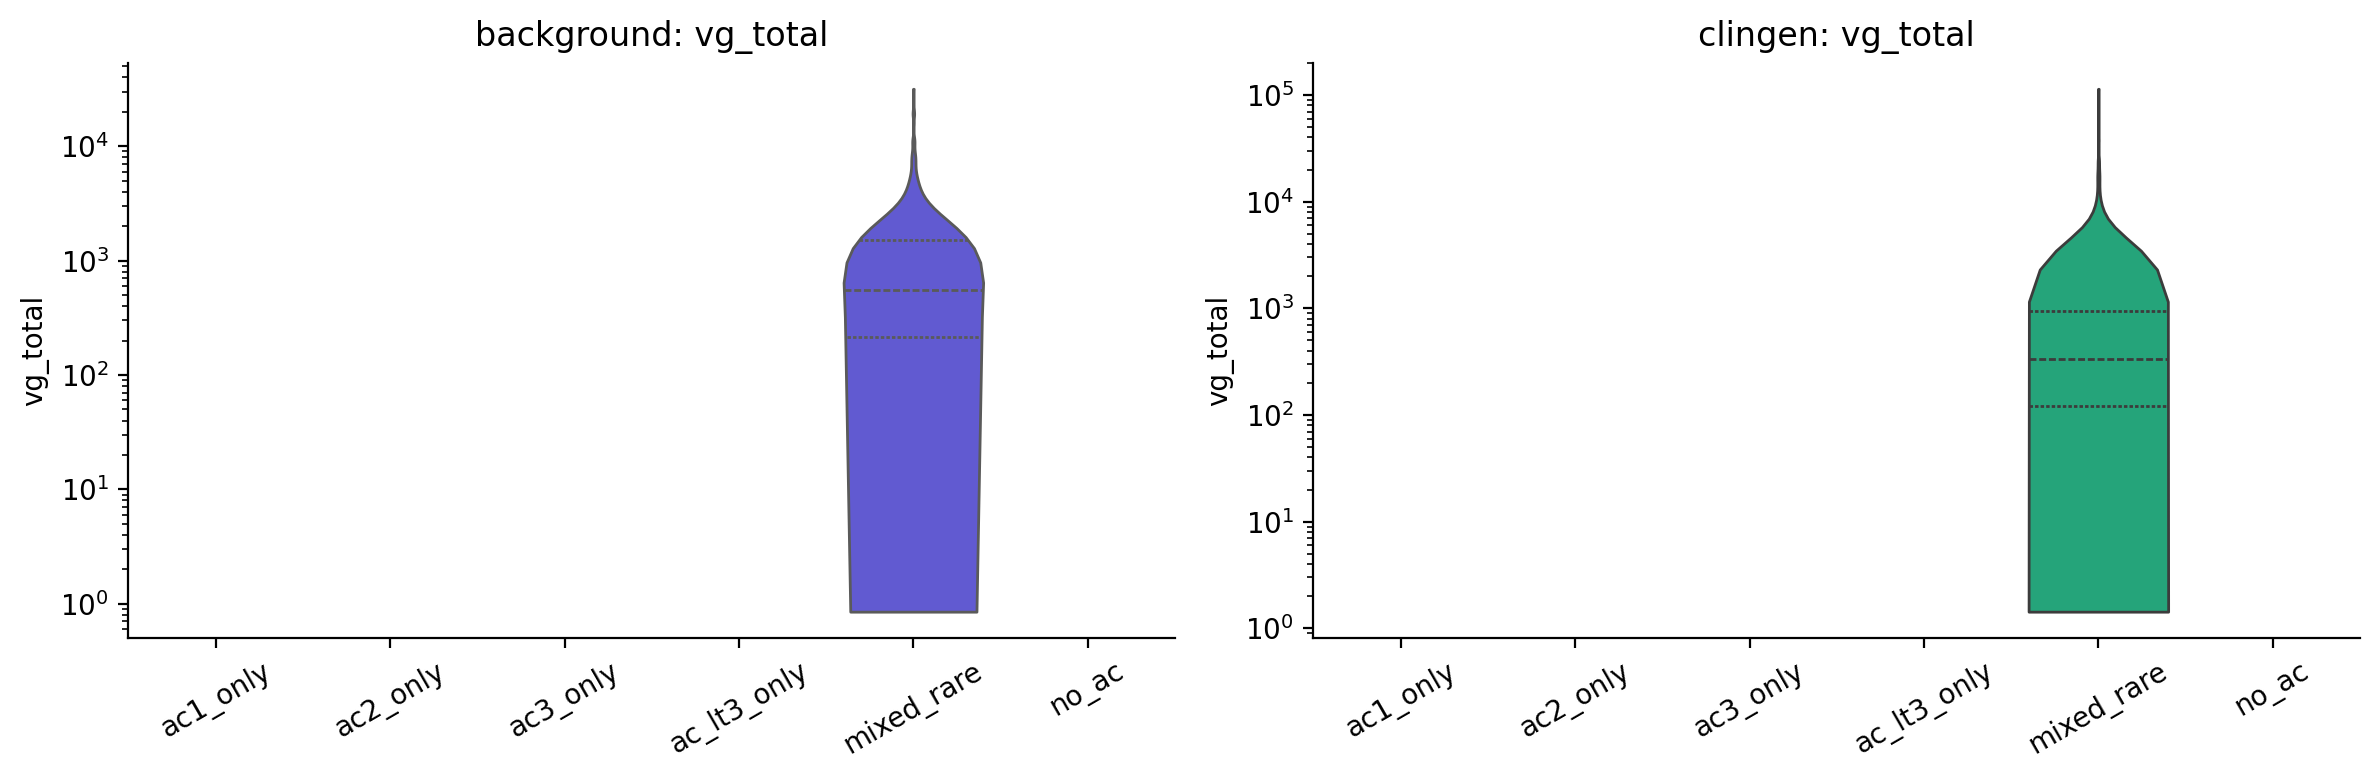

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:291: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g for g, sub in df.groupby(group_col) if len(sub) >= min_n]
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0

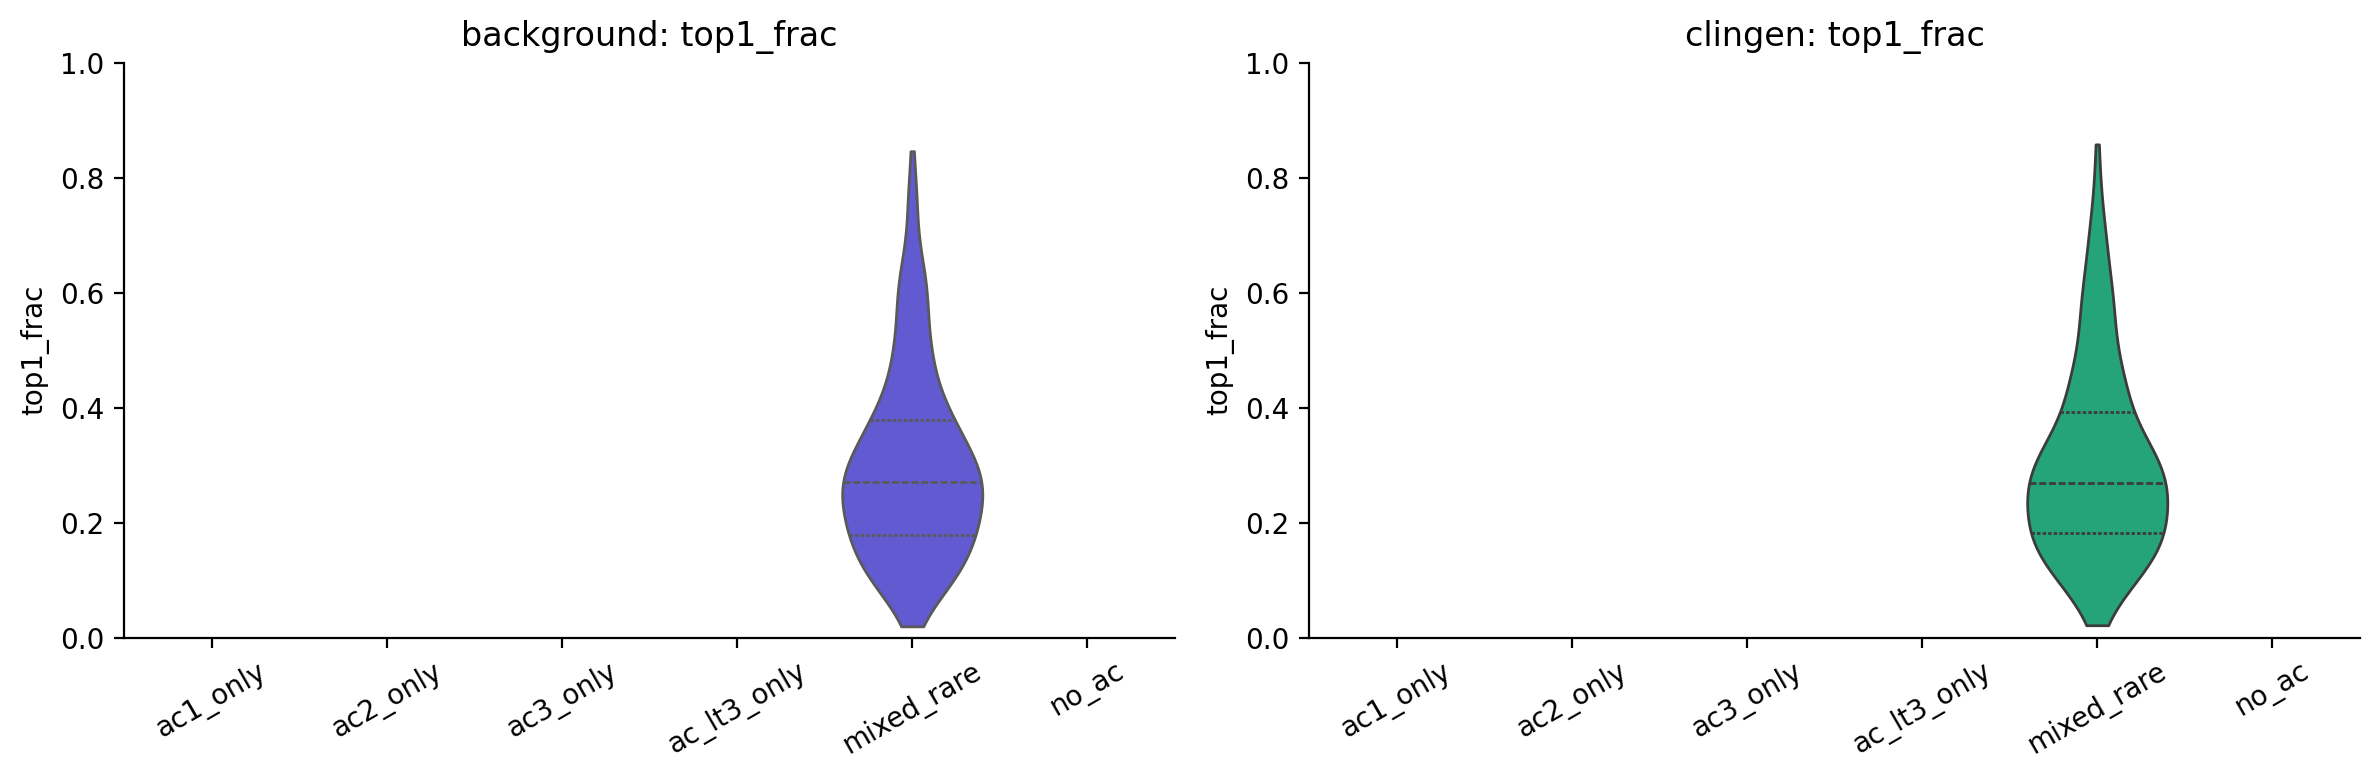

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:291: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g for g, sub in df.groupby(group_col) if len(sub) >= min_n]
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0

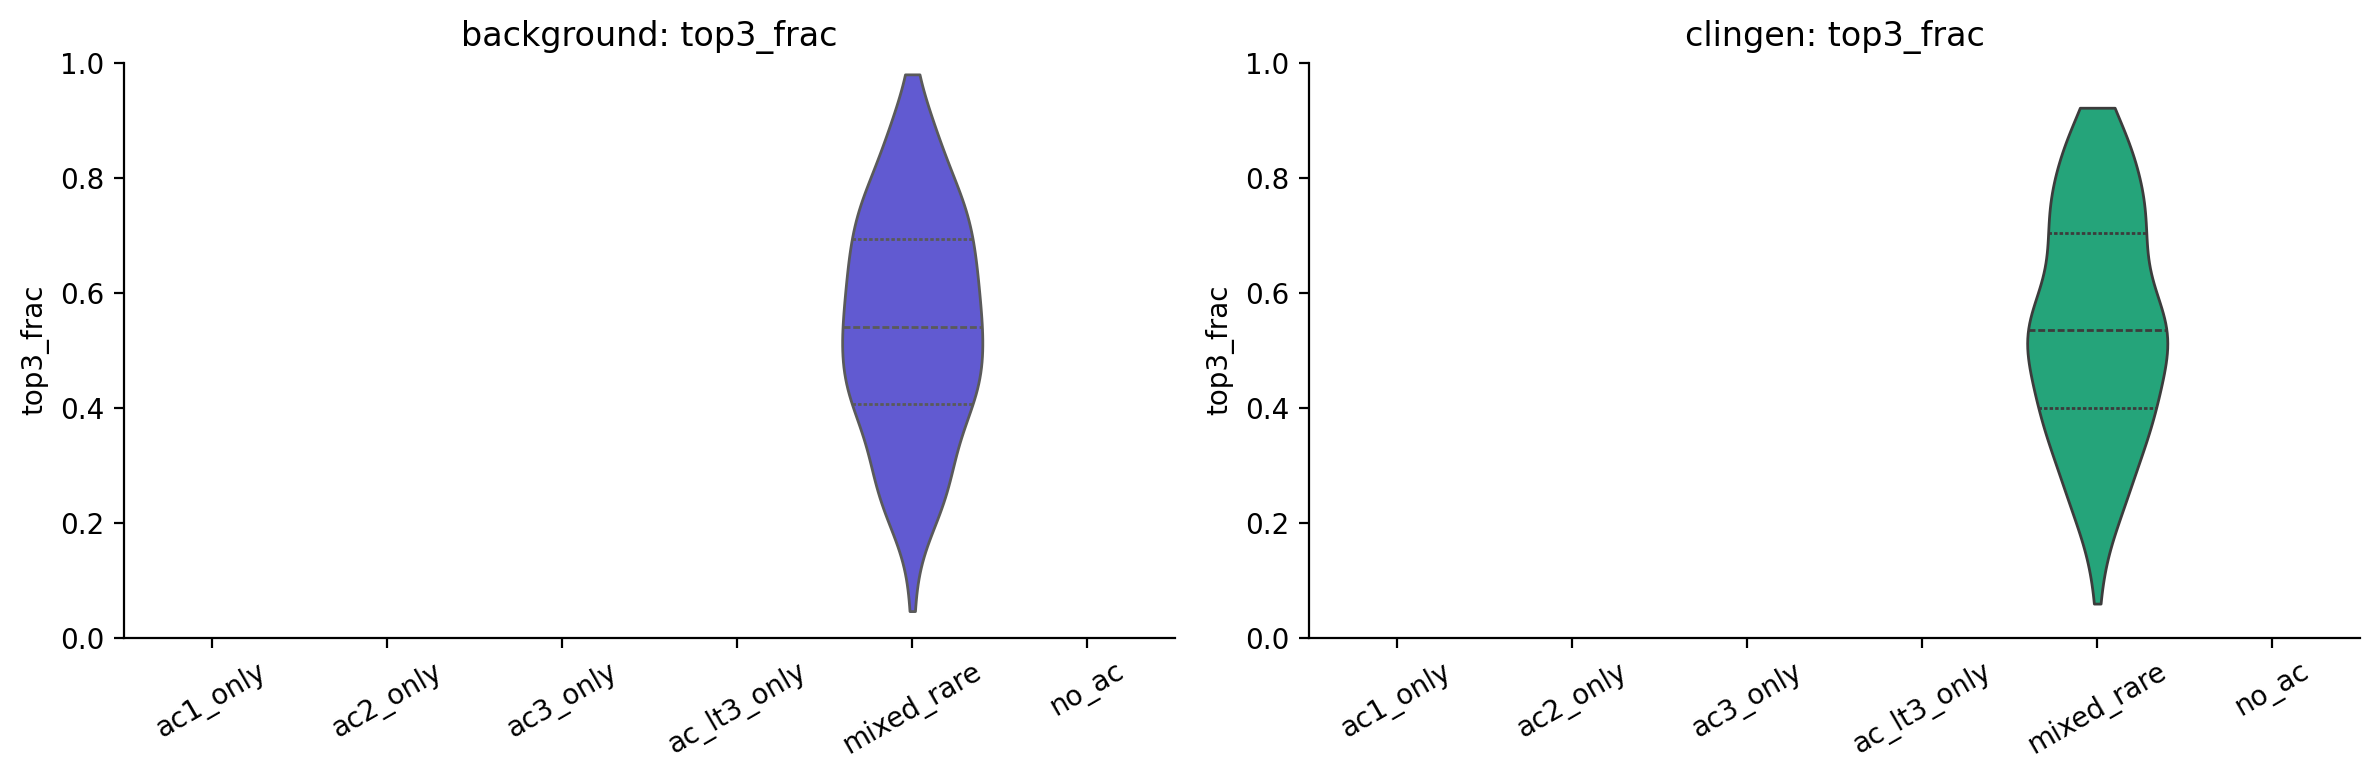

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:291: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g for g, sub in df.groupby(group_col) if len(sub) >= min_n]
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0

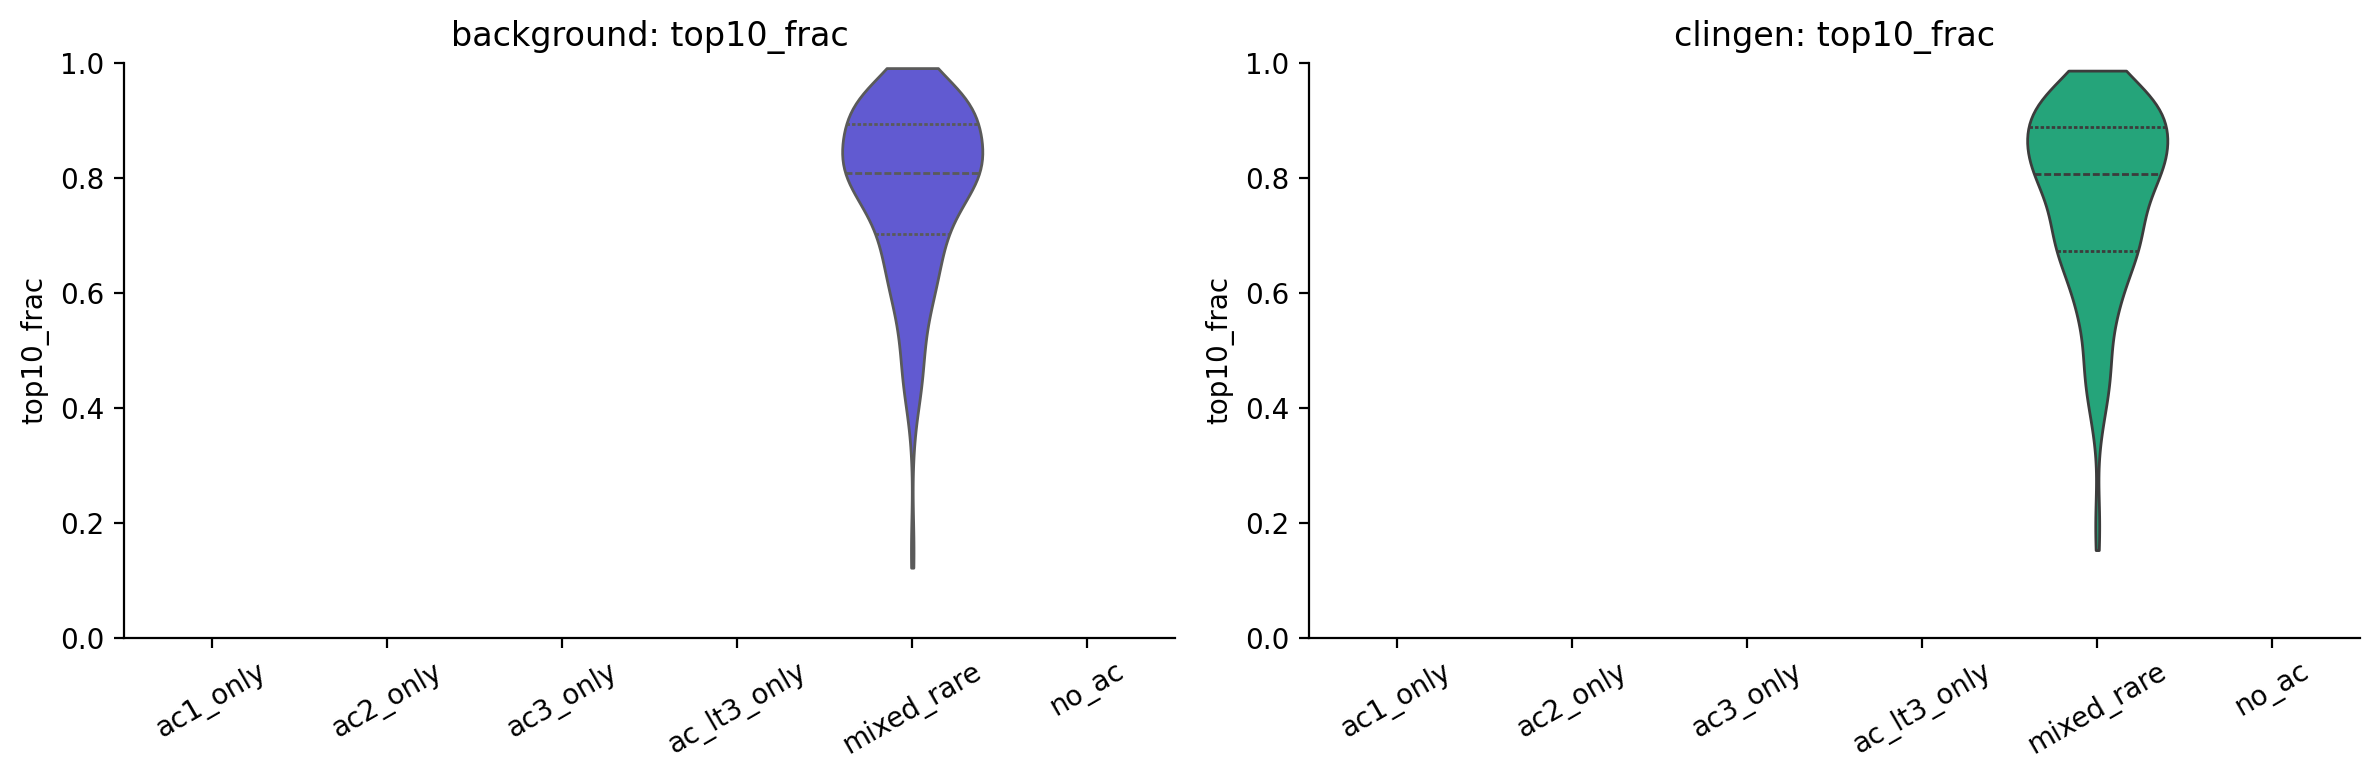

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:291: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g for g, sub in df.groupby(group_col) if len(sub) >= min_n]
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0

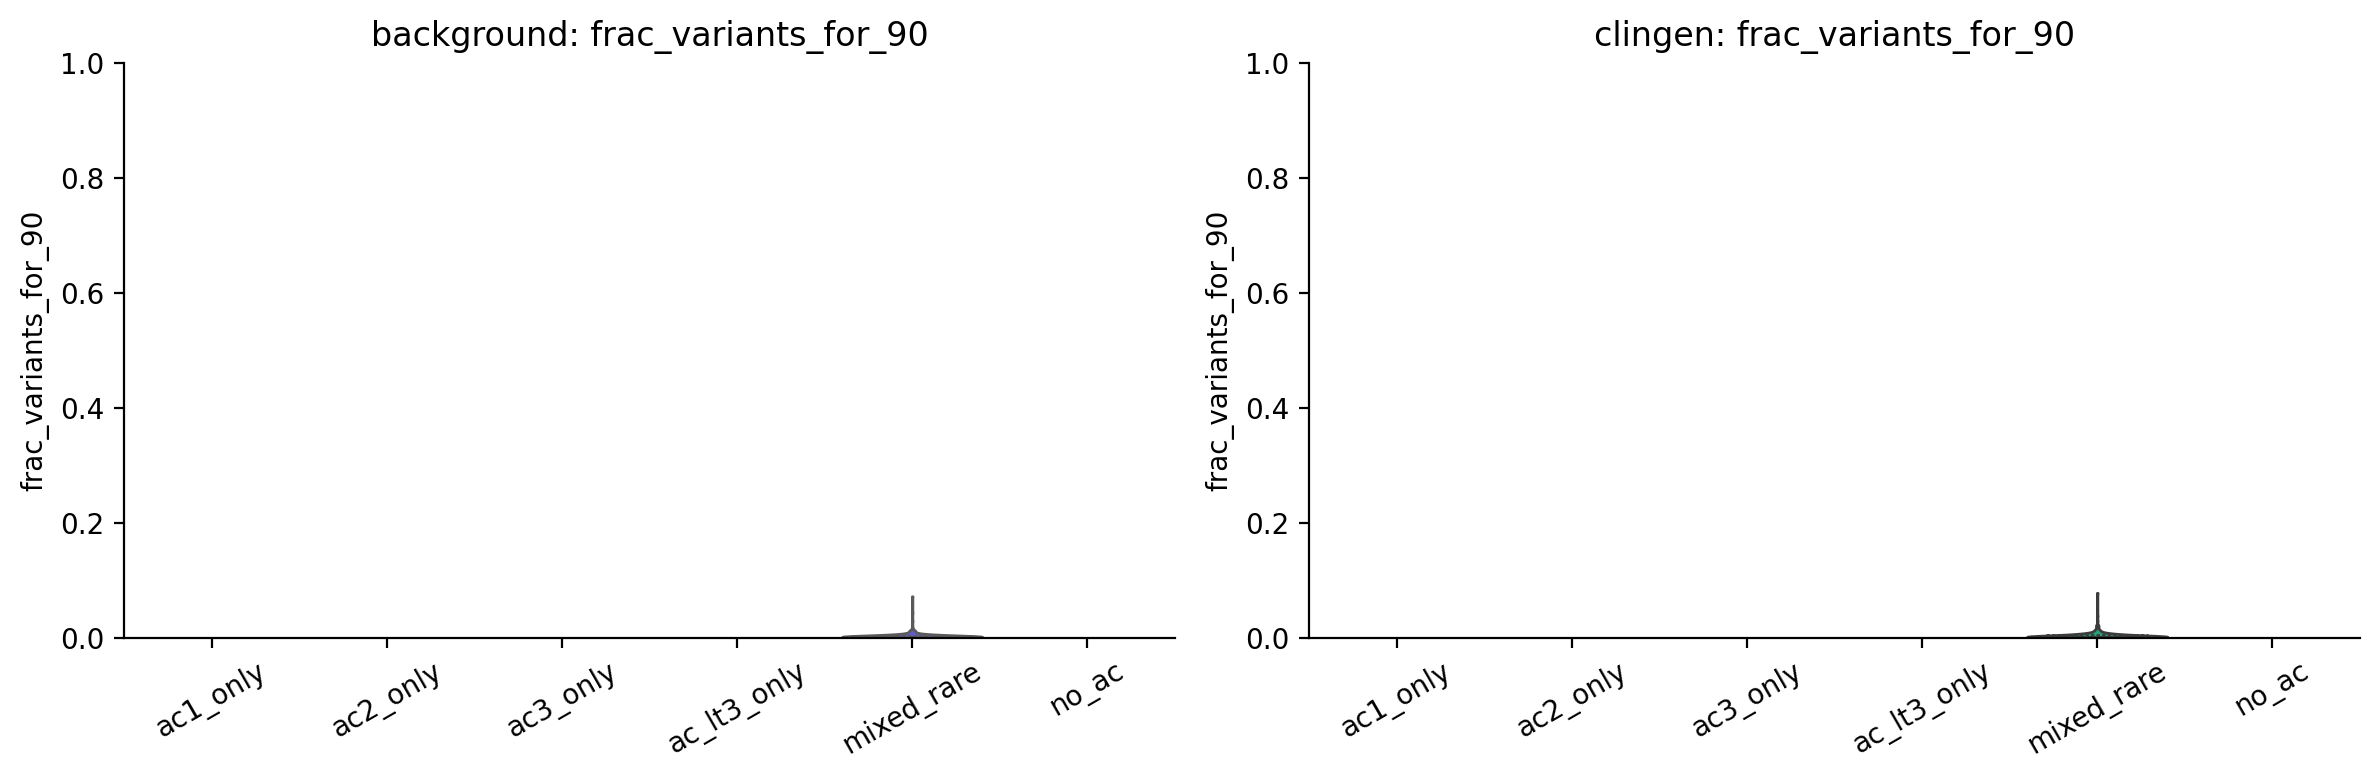

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:291: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g for g, sub in df.groupby(group_col) if len(sub) >= min_n]
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/4111998693.py:477: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0

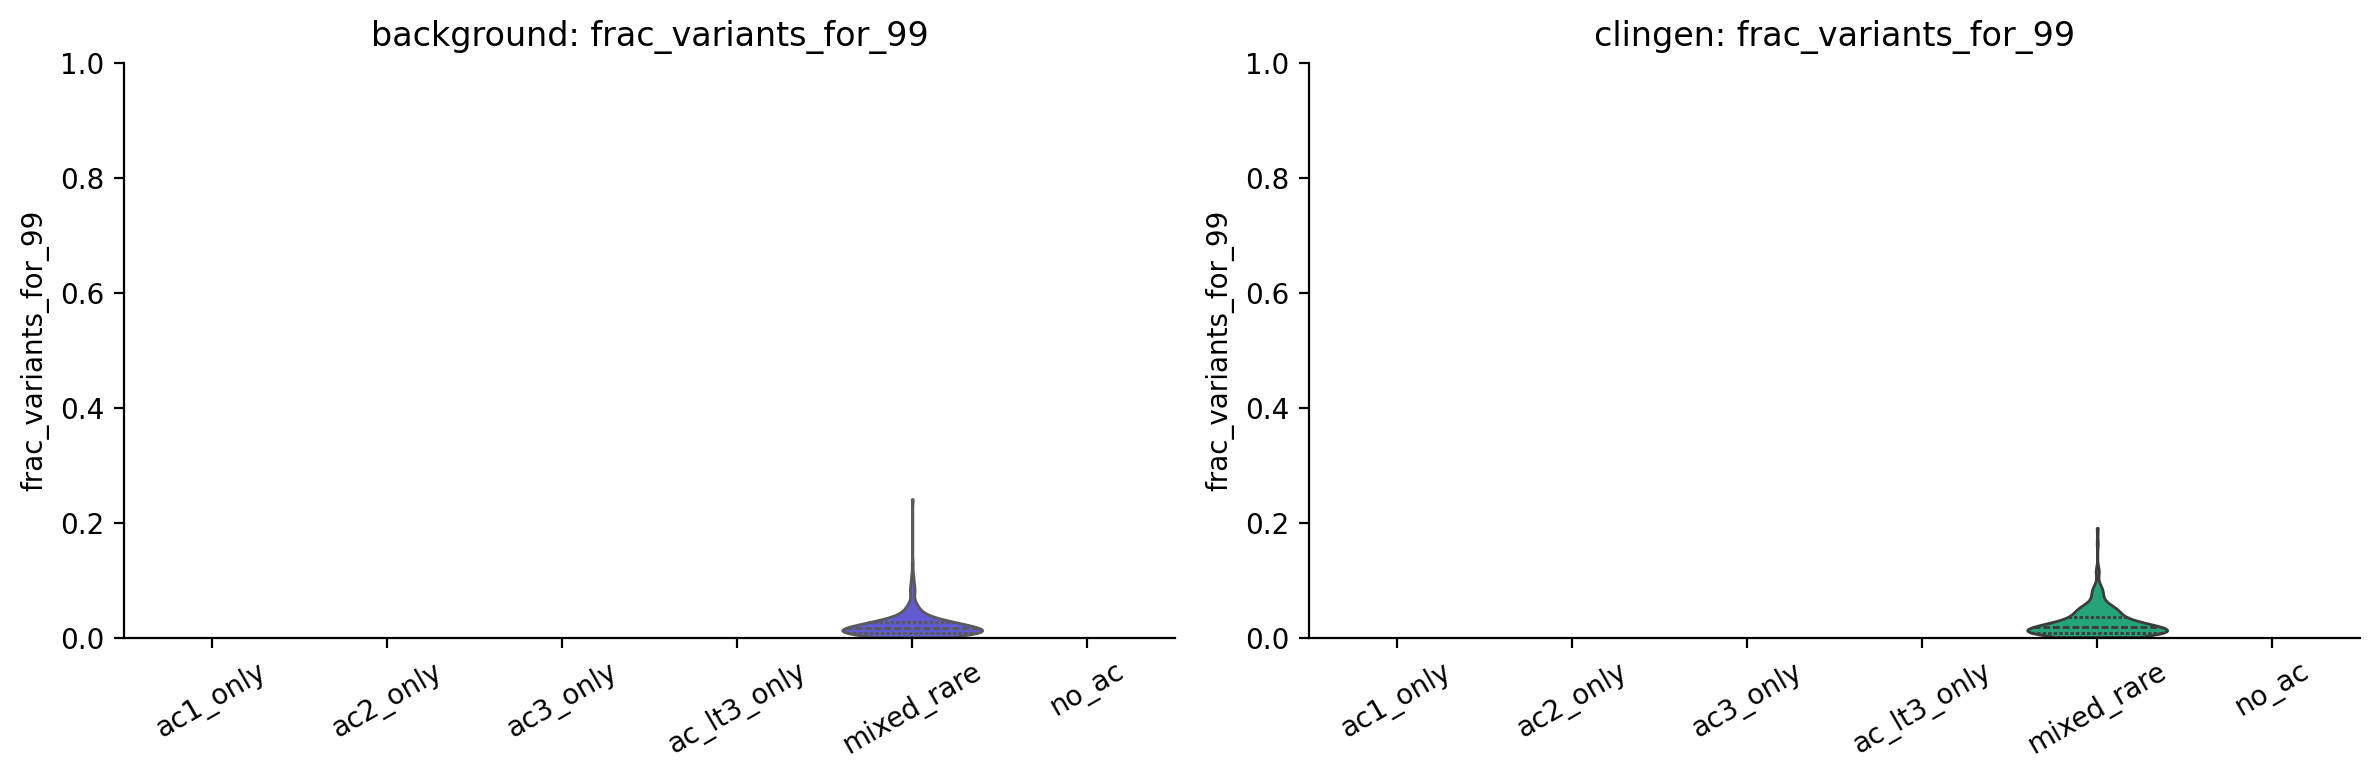


--- mann-whitney: dataset, abs_sum_score ---
           group_a          group_b         metric  n_a  n_b   u_stat  \
2       background     clingen_null  abs_sum_score  349  316  91145.0   
0       background  background_null  abs_sum_score  349  349  99052.0   
5          clingen     clingen_null  abs_sum_score  316  316  80504.0   
3  background_null          clingen  abs_sum_score  349  316  23072.0   
4  background_null     clingen_null  abs_sum_score  349  316  59831.0   
1       background          clingen  abs_sum_score  349  316  58259.0   

        p_value         p_fdr  
2  5.651973e-48  3.391184e-47  
0  1.572973e-46  4.718918e-46  
5  1.720135e-40  3.440271e-40  
3  1.995812e-38  2.993718e-38  
4  5.807971e-02  6.969565e-02  
1  2.077805e-01  2.077805e-01  

--- mann-whitney: dataset, vg_total ---
      group_a  group_b    metric  n_a  n_b   u_stat   p_value     p_fdr
0  background  clingen  vg_total  254  259  38400.0  0.001037  0.001037

--- mann-whitney: dataset, top1_

In [68]:
from itertools import combinations
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from scipy import stats

from config import SOURCE_PALETTE

AC_PATHS_OBS = {
    'clingen': Path(
        '/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/'
        'dataset3_ClinGen/ClinGen_variants.tsv'
    ),
    'background': Path(
        '/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/'
        'dataset4_background/background_variants.tsv'
    ),
}


def _load_variant_scores_no_dedup(
    path: str | Path,
    label: str,
    columns: list[str] | None = None,
) -> pl.DataFrame:
    """load variant scores without track-level dedup.

    args:
        path (str | Path): variant file path.
        label (str): dataset label.
        columns (list[str] | None): extra columns to include.

    returns:
        pl.DataFrame: variant-level scores with gene_id.

    raises:
        FileNotFoundError: when the file is missing.
        ValueError: when required columns are missing.
    """
    columns = [] if columns is None else columns

    file_path = Path(path)
    if not file_path.exists():
        raise FileNotFoundError(f'missing variant file: {file_path}')

    schema_cols = pl.read_parquet(file_path, n_rows=0).columns
    if 'raw_score' in schema_cols:
        score_col = 'raw_score'
    elif 'score' in schema_cols:
        score_col = 'score'
    else:
        raise ValueError(f'missing raw_score/score column in {file_path}')

    base_cols = [score_col, 'variant_id']
    if 'gene_id' in schema_cols:
        base_cols.append('gene_id')
    elif 'gene_tag' in schema_cols:
        base_cols.append('gene_tag')
    else:
        raise ValueError('missing gene_id or gene_tag column')

    missing = [c for c in base_cols + columns if c not in schema_cols]
    if missing:
        raise ValueError(f'missing columns in {file_path}: {missing}')

    select_cols = list(dict.fromkeys(base_cols + columns))

    df = (
        pl.scan_parquet(file_path)
        .select(select_cols)
        .filter(pl.col(score_col).is_not_null())
        .with_columns(
            pl.col(score_col).alias('raw_score'),
            pl.col(score_col).abs().alias('abs_score'),
            pl.lit(label).alias('dataset'),
        )
    )

    if 'gene_id' not in df.columns and 'gene_tag' in df.columns:
        df = df.with_columns(
            pl.col('gene_tag').str.split('|').list.get(0).alias('gene_id')
        )

    return df.select(
        ['variant_id', 'gene_id', 'raw_score', 'abs_score', 'dataset'] + columns
    ).collect()


def _compute_gene_metrics_no_dedup(
    df: pd.DataFrame,
    ac_col: str | None = None,
) -> pd.DataFrame:
    """compute variance architecture and cumulative absolute scores per gene.

    args:
        df (pd.DataFrame): variant-level scores with gene_id.
        ac_col (str | None): allele count column for observed datasets.

    returns:
        pd.DataFrame: gene-level metrics.
    """
    rows: list[dict[str, float | int | str]] = []

    for gene_id, sub in df.groupby('gene_id', sort=False):
        raw = sub['raw_score'].to_numpy()
        n_variants = int(len(raw))
        abs_sum_score = float(np.abs(raw).sum())

        v_total = np.nan
        top1_frac = np.nan
        top3_frac = np.nan
        top10_frac = np.nan
        k90 = 0
        k99 = 0
        frac_variants_for_90 = np.nan
        frac_variants_for_99 = np.nan

        if ac_col is not None and ac_col in sub.columns:
            ac = sub[ac_col].to_numpy()
            v_i = ac * (raw**2)
            v_sorted = np.sort(v_i)[::-1]
            v_total = float(v_sorted.sum())

            if v_total > 0 and n_variants > 0:
                top1_frac = float(v_sorted[:1].sum() / v_total)
                top3_frac = float(v_sorted[:3].sum() / v_total)
                top10_frac = float(v_sorted[:10].sum() / v_total)
                cumulative = np.cumsum(v_sorted) / v_total
                k90 = int(np.searchsorted(cumulative, 0.9) + 1)
                k99 = int(np.searchsorted(cumulative, 0.99) + 1)
                frac_variants_for_90 = float(k90 / n_variants)
                frac_variants_for_99 = float(k99 / n_variants)

        rows.append({
            'gene_id': gene_id,
            'n_variants': n_variants,
            'abs_sum_score': abs_sum_score,
            'vg_total': v_total,
            'top1_frac': top1_frac,
            'top3_frac': top3_frac,
            'top10_frac': top10_frac,
            'frac_variants_for_90': frac_variants_for_90,
            'frac_variants_for_99': frac_variants_for_99,
            'count_variants_for_90': k90,
            'count_variants_for_99': k99,
        })

    return pd.DataFrame(rows)


def _load_ac_table(path: str | Path) -> pd.DataFrame:
    """load allele counts and map to gene_id.

    args:
        path (str | Path): tsv path with variant_id, AC, and gene_tag.

    returns:
        pd.DataFrame: per-variant AC with gene_id.
    """
    df = pd.read_csv(path, sep='\t')
    if 'gene_tag' not in df.columns or 'AC' not in df.columns:
        raise ValueError(f'missing gene_tag or AC in {path}')
    df['gene_id'] = df['gene_tag'].str.split('|').str[0]
    return df[['variant_id', 'gene_id', 'AC']]


def _merge_ac_into_variants(
    variants: pl.DataFrame,
    ac_df: pd.DataFrame,
) -> pd.DataFrame:
    """merge ac into variant scores for observed datasets.

    args:
        variants (pl.DataFrame): variant-level scores.
        ac_df (pd.DataFrame): variant-level AC table.

    returns:
        pd.DataFrame: merged table with AC when available.

    raises:
        ValueError: when AC cannot be merged.
    """
    var_df = variants.to_pandas()
    merged = var_df.merge(ac_df, on=['variant_id', 'gene_id'], how='left')

    if merged['AC'].notna().any():
        return merged

    # fallback in case gene_id formatting differs between sources
    merged = var_df.merge(ac_df[['variant_id', 'AC']], on='variant_id', how='left')
    if merged['AC'].notna().any():
        return merged

    raise ValueError('failed to merge AC; check variant_id and gene_id formats')


def _summarize_rarity_by_gene(df: pd.DataFrame) -> pd.DataFrame:
    """summarize singleton/doubleton/tripleton composition per gene.

    args:
        df (pd.DataFrame): variant-level AC with gene_id.

    returns:
        pd.DataFrame: gene-level rarity metrics.
    """
    agg = df.groupby('gene_id').agg(
        n_variants_ac=('AC', 'size'),
        n_singleton=('AC', lambda s: int((s == 1).sum())),
        n_doubleton=('AC', lambda s: int((s == 2).sum())),
        n_tripleton=('AC', lambda s: int((s == 3).sum())),
    )
    agg = agg.reset_index()

    agg['has_singleton'] = agg['n_singleton'] > 0
    agg['singleton_only'] = agg['n_singleton'] == agg['n_variants_ac']
    agg['doubleton_only'] = agg['n_doubleton'] == agg['n_variants_ac']
    agg['tripleton_only'] = agg['n_tripleton'] == agg['n_variants_ac']
    agg['ac_lt3_only'] = (agg['n_singleton'] + agg['n_doubleton']) == agg['n_variants_ac']
    agg['mixed_rare'] = (
        (agg['n_singleton'] > 0).astype(int)
        + (agg['n_doubleton'] > 0).astype(int)
        + (agg['n_tripleton'] > 0).astype(int)
    ) >= 2

    def _category(row: pd.Series) -> str:
        if row['n_variants_ac'] == 0:
            return 'no_ac'
        if row['singleton_only']:
            return 'ac1_only'
        if row['doubleton_only']:
            return 'ac2_only'
        if row['tripleton_only']:
            return 'ac3_only'
        if row['ac_lt3_only']:
            return 'ac_lt3_only'
        return 'mixed_rare'

    agg['rarity_category'] = agg.apply(_category, axis=1)

    return agg


def _bh_adjust(pvals: Iterable[float]) -> list[float]:
    """benjamini-hochberg adjust.

    args:
        pvals (Iterable[float]): raw p-values.

    returns:
        list[float]: adjusted p-values in original order.
    """
    pvals = np.array(list(pvals), dtype=float)
    order = np.argsort(pvals)
    ranked = pvals[order]
    m = len(ranked)
    adj = np.empty(m, dtype=float)
    cum_min = 1.0
    for i in range(m - 1, -1, -1):
        rank = i + 1
        val = ranked[i] * m / rank
        cum_min = min(cum_min, val)
        adj[i] = cum_min
    out = np.empty(m, dtype=float)
    out[order] = adj
    return out.tolist()


def _mw_pairwise(
    df: pd.DataFrame,
    group_col: str,
    metric: str,
    min_n: int = 20,
) -> pd.DataFrame:
    """pairwise mann-whitney with bh correction.

    args:
        df (pd.DataFrame): input table.
        group_col (str): grouping column.
        metric (str): numeric column to test.
        min_n (int): minimum group size.

    returns:
        pd.DataFrame: pairwise results.
    """
    rows = []
    groups = [g for g, sub in df.groupby(group_col) if len(sub) >= min_n]
    for a, b in combinations(groups, 2):
        a_vals = df.loc[df[group_col] == a, metric].dropna()
        b_vals = df.loc[df[group_col] == b, metric].dropna()
        if len(a_vals) < min_n or len(b_vals) < min_n:
            continue
        stat, p_val = stats.mannwhitneyu(a_vals, b_vals, alternative='two-sided')
        rows.append({
            'group_a': a,
            'group_b': b,
            'metric': metric,
            'n_a': len(a_vals),
            'n_b': len(b_vals),
            'u_stat': float(stat),
            'p_value': float(p_val),
        })
    if not rows:
        return pd.DataFrame()
    out = pd.DataFrame(rows)
    out['p_fdr'] = _bh_adjust(out['p_value'])
    return out


def _annotate_pairwise(
    ax: plt.Axes,
    stats_df: pd.DataFrame,
    order: list[str],
    y_max: float,
    y_min: float,
    label_fmt: str = 'p_fdr={p:.2g}, u={u:.2g}',
    show_all: bool = False,
) -> None:
    """annotate pairwise stats on a single axis.

    args:
        ax (plt.Axes): target axis.
        stats_df (pd.DataFrame): pairwise stats with group_a, group_b, p_fdr.
        order (list[str]): x-axis order.
        y_max (float): max y value.
        y_min (float): min y value.
        label_fmt (str): label format.
        show_all (bool): show all pairs regardless of p_fdr.

    returns:
        None
    """
    if stats_df.empty:
        return

    pair_stats = stats_df.sort_values('p_fdr')
    scale = ax.get_yscale()
    current_level = 1

    for _, row in pair_stats.iterrows():
        if row['group_a'] not in order or row['group_b'] not in order:
            continue
        if not show_all and row['p_fdr'] >= 0.05:
            continue

        x1 = order.index(row['group_a'])
        x2 = order.index(row['group_b'])
        if x1 == x2:
            continue

        if scale == 'log':
            base = y_max * 1.05
            step = 1.12 ** current_level
            y = base * step
            y_top = y * 1.06
        else:
            base = y_max + (y_max - y_min) * 0.05
            step = (y_max - y_min) * 0.06
            y = base + step * current_level
            y_top = y + step * 0.35

        x_low, x_high = sorted([x1, x2])
        ax.plot(
            [x_low, x_low, x_high, x_high],
            [y, y_top, y_top, y],
            color='black',
            linewidth=1,
        )
        label = label_fmt.format(p=row['p_fdr'], u=row['u_stat'])
        ax.text(
            (x_low + x_high) / 2,
            y_top,
            label,
            ha='center',
            va='bottom',
            fontsize=8,
        )
        current_level += 1


def _plot_violin(
    df: pd.DataFrame,
    x: str,
    y: str,
    title: str,
    log_scale: bool = False,
    hue: str | None = None,
    order: list[str] | None = None,
    stats_group_col: str | None = None,
) -> None:
    """plot violin with optional log scale and stats.

    args:
        df (pd.DataFrame): input data.
        x (str): categorical axis.
        y (str): numeric metric.
        title (str): plot title.
        log_scale (bool): log10 y scale.
        hue (str | None): hue column.
        order (list[str] | None): axis order.
        stats_group_col (str | None): group column for stats.

    returns:
        None
    """
    fig, ax = plt.subplots(figsize=(9, 4), dpi=200)
    palette = SOURCE_PALETTE if hue == 'dataset' or x == 'dataset' else None
    sns.violinplot(
        data=df,
        x=x,
        y=y,
        hue=hue,
        cut=0,
        inner='quartile',
        palette=palette,
        order=order,
        linewidth=1,
        ax=ax,
    )
    if log_scale:
        ax.set_yscale('log')
    if y in fraction_metrics and not log_scale:
        ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    sns.despine(ax=ax)

    if stats_group_col:
        stats_df = _mw_pairwise(df, stats_group_col, y)
        y_vals = df[y].replace([np.inf, -np.inf], np.nan).dropna()
        if not y_vals.empty:
            y_max = float(y_vals.max())
            y_min = float(y_vals.min())
            if order is None:
                order = list(df[x].dropna().unique())
            _annotate_pairwise(ax, stats_df, order, y_max, y_min, show_all=True)

    plt.tight_layout()
    plt.show()


def _plot_rarity_violin_by_dataset(
    df: pd.DataFrame,
    metric: str,
    log_scale: bool,
) -> None:
    """plot rarity violins per dataset with stats.

    args:
        df (pd.DataFrame): observed metrics with rarity_category.
        metric (str): metric to plot.
        log_scale (bool): log10 y scale.

    returns:
        None
    """
    datasets = ['background', 'clingen']
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 4), dpi=200)
    if len(datasets) == 1:
        axes = [axes]

    for ax, dataset in zip(axes, datasets):
        subset = df[df['dataset'] == dataset].copy()
        subset['rarity_category'] = pd.Categorical(
            subset['rarity_category'],
            categories=rarity_order,
            ordered=True,
        )
        order = rarity_order
        palette = [SOURCE_PALETTE.get(dataset, '#999999')] * len(order)

        sns.violinplot(
            data=subset,
            x='rarity_category',
            y=metric,
            order=order,
            cut=0,
            inner='quartile',
            palette=palette,
            linewidth=1,
            ax=ax,
        )
        if log_scale:
            ax.set_yscale('log')
        if metric in fraction_metrics and not log_scale:
            ax.set_ylim(0, 1)
        ax.set_title(f'{dataset}: {metric}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)
        sns.despine(ax=ax)

        stats_df = _mw_pairwise(subset, 'rarity_category', metric)
        y_vals = subset[metric].replace([np.inf, -np.inf], np.nan).dropna()
        if not y_vals.empty:
            y_max = float(y_vals.max())
            y_min = float(y_vals.min())
            _annotate_pairwise(ax, stats_df, order, y_max, y_min, show_all=True)

    plt.tight_layout()
    plt.show()


def build_gene_metrics_tables() -> tuple[pd.DataFrame, pd.DataFrame]:
    """build gene-level metrics and rarity annotations.

    returns:
        tuple[pd.DataFrame, pd.DataFrame]: gene metrics, rarity table.
    """
    variant_paths = {
        'clingen': CLINGEN_VAR,
        'background': BG_VAR,
        'clingen_null': CLINGEN_NULL_VAR,
        'background_null': BG_NULL_VAR,
    }

    ac_tables = {
        label: _load_ac_table(path)
        for label, path in AC_PATHS_OBS.items()
    }

    metrics_frames: list[pd.DataFrame] = []
    for label, path in variant_paths.items():
        df = _load_variant_scores_no_dedup(path, label)

        if label in ac_tables:
            merged = _merge_ac_into_variants(df, ac_tables[label])
            metrics = _compute_gene_metrics_no_dedup(merged, ac_col='AC')
        else:
            metrics = _compute_gene_metrics_no_dedup(df.to_pandas(), ac_col=None)

        metrics['dataset'] = label
        metrics_frames.append(metrics)

    gene_metrics = pd.concat(metrics_frames, ignore_index=True)

    rarity_frames: list[pd.DataFrame] = []
    for label, ac_df in ac_tables.items():
        rarity = _summarize_rarity_by_gene(ac_df)
        rarity['dataset'] = label
        rarity_frames.append(rarity)

    rarity_table = pd.concat(rarity_frames, ignore_index=True)

    return gene_metrics, rarity_table


gene_metrics_df, rarity_df = build_gene_metrics_tables()

observed_metrics_df = gene_metrics_df[
    gene_metrics_df['dataset'].isin(['clingen', 'background'])
].merge(rarity_df, on=['gene_id', 'dataset'], how='left')

observed_metrics_df['rarity_category'] = observed_metrics_df['rarity_category'].fillna(
    'no_ac'
)

metric_list = [
    'abs_sum_score',
    'vg_total',
    'top1_frac',
    'top3_frac',
    'top10_frac',
    'frac_variants_for_90',
    'frac_variants_for_99',
]

log_metrics = {'abs_sum_score', 'vg_total'}
fraction_metrics = {
    'top1_frac',
    'top3_frac',
    'top10_frac',
    'frac_variants_for_90',
    'frac_variants_for_99',
}

rarity_order = [
    'ac1_only',
    'ac2_only',
    'ac3_only',
    'ac_lt3_only',
    'mixed_rare',
    'no_ac',
]

dataset_order = ['background', 'clingen', 'background_null', 'clingen_null']

for metric in metric_list:
    _plot_violin(
        gene_metrics_df,
        x='dataset',
        y=metric,
        title=f'dataset comparison: {metric}',
        log_scale=metric in log_metrics,
        order=dataset_order,
        stats_group_col='dataset',
    )

for metric in metric_list:
    _plot_rarity_violin_by_dataset(
        observed_metrics_df,
        metric=metric,
        log_scale=metric in log_metrics,
    )

for metric in metric_list:
    stats_df = _mw_pairwise(gene_metrics_df, 'dataset', metric)
    if not stats_df.empty:
        print(f'\n--- mann-whitney: dataset, {metric} ---')
        print(stats_df.sort_values('p_fdr').head(10))

for metric in metric_list:
    stats_df = _mw_pairwise(observed_metrics_df, 'rarity_category', metric)
    if not stats_df.empty:
        print(f'\n--- mann-whitney: rarity, {metric} ---')
        print(stats_df.sort_values('p_fdr').head(10))


In [69]:
def summarize_all_stats(
    gene_metrics: pd.DataFrame,
    observed_metrics: pd.DataFrame,
    metrics: list[str],
) -> dict[str, pd.DataFrame]:
    """summarize all pairwise stats with fdr correction.

    args:
        gene_metrics (pd.DataFrame): all datasets.
        observed_metrics (pd.DataFrame): observed only, with rarity categories.
        metrics (list[str]): metrics to test.

    returns:
        dict[str, pd.DataFrame]: results tables.
    """
    out: dict[str, pd.DataFrame] = {}

    dataset_rows = []
    for metric in metrics:
        stats_df = _mw_pairwise(gene_metrics, 'dataset', metric)
        if not stats_df.empty:
            dataset_rows.append(stats_df)
    out['dataset_pairwise'] = (
        pd.concat(dataset_rows, ignore_index=True)
        if dataset_rows
        else pd.DataFrame()
    )

    rarity_rows = []
    for metric in metrics:
        stats_df = _mw_pairwise(observed_metrics, 'rarity_category', metric)
        if not stats_df.empty:
            rarity_rows.append(stats_df)
    out['rarity_pairwise'] = (
        pd.concat(rarity_rows, ignore_index=True)
        if rarity_rows
        else pd.DataFrame()
    )

    rarity_by_dataset_rows = []
    for dataset in ['clingen', 'background']:
        subset = observed_metrics[observed_metrics['dataset'] == dataset]
        for metric in metrics:
            stats_df = _mw_pairwise(subset, 'rarity_category', metric)
            if not stats_df.empty:
                stats_df = stats_df.assign(dataset=dataset)
                rarity_by_dataset_rows.append(stats_df)
    out['rarity_pairwise_by_dataset'] = (
        pd.concat(rarity_by_dataset_rows, ignore_index=True)
        if rarity_by_dataset_rows
        else pd.DataFrame()
    )

    return out


all_stats = summarize_all_stats(gene_metrics_df, observed_metrics_df, metric_list)

for name, df in all_stats.items():
    print(f'\n--- {name} ---')
    if df.empty:
        print('no results')
    else:
        print(df.sort_values('p_fdr').head(30))



--- dataset_pairwise ---
            group_a          group_b                metric  n_a  n_b   u_stat  \
2        background     clingen_null         abs_sum_score  349  316  91145.0   
0        background  background_null         abs_sum_score  349  349  99052.0   
5           clingen     clingen_null         abs_sum_score  316  316  80504.0   
3   background_null          clingen         abs_sum_score  349  316  23072.0   
6        background          clingen              vg_total  254  259  38400.0   
11       background          clingen  frac_variants_for_99  254  259  29173.0   
4   background_null     clingen_null         abs_sum_score  349  316  59831.0   
1        background          clingen         abs_sum_score  349  316  58259.0   
10       background          clingen  frac_variants_for_90  254  259  31453.0   
9        background          clingen            top10_frac  254  259  34238.0   
7        background          clingen             top1_frac  254  259  32496.0   
8 

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/2300600673.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/2300600673.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_29835/2300600673.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


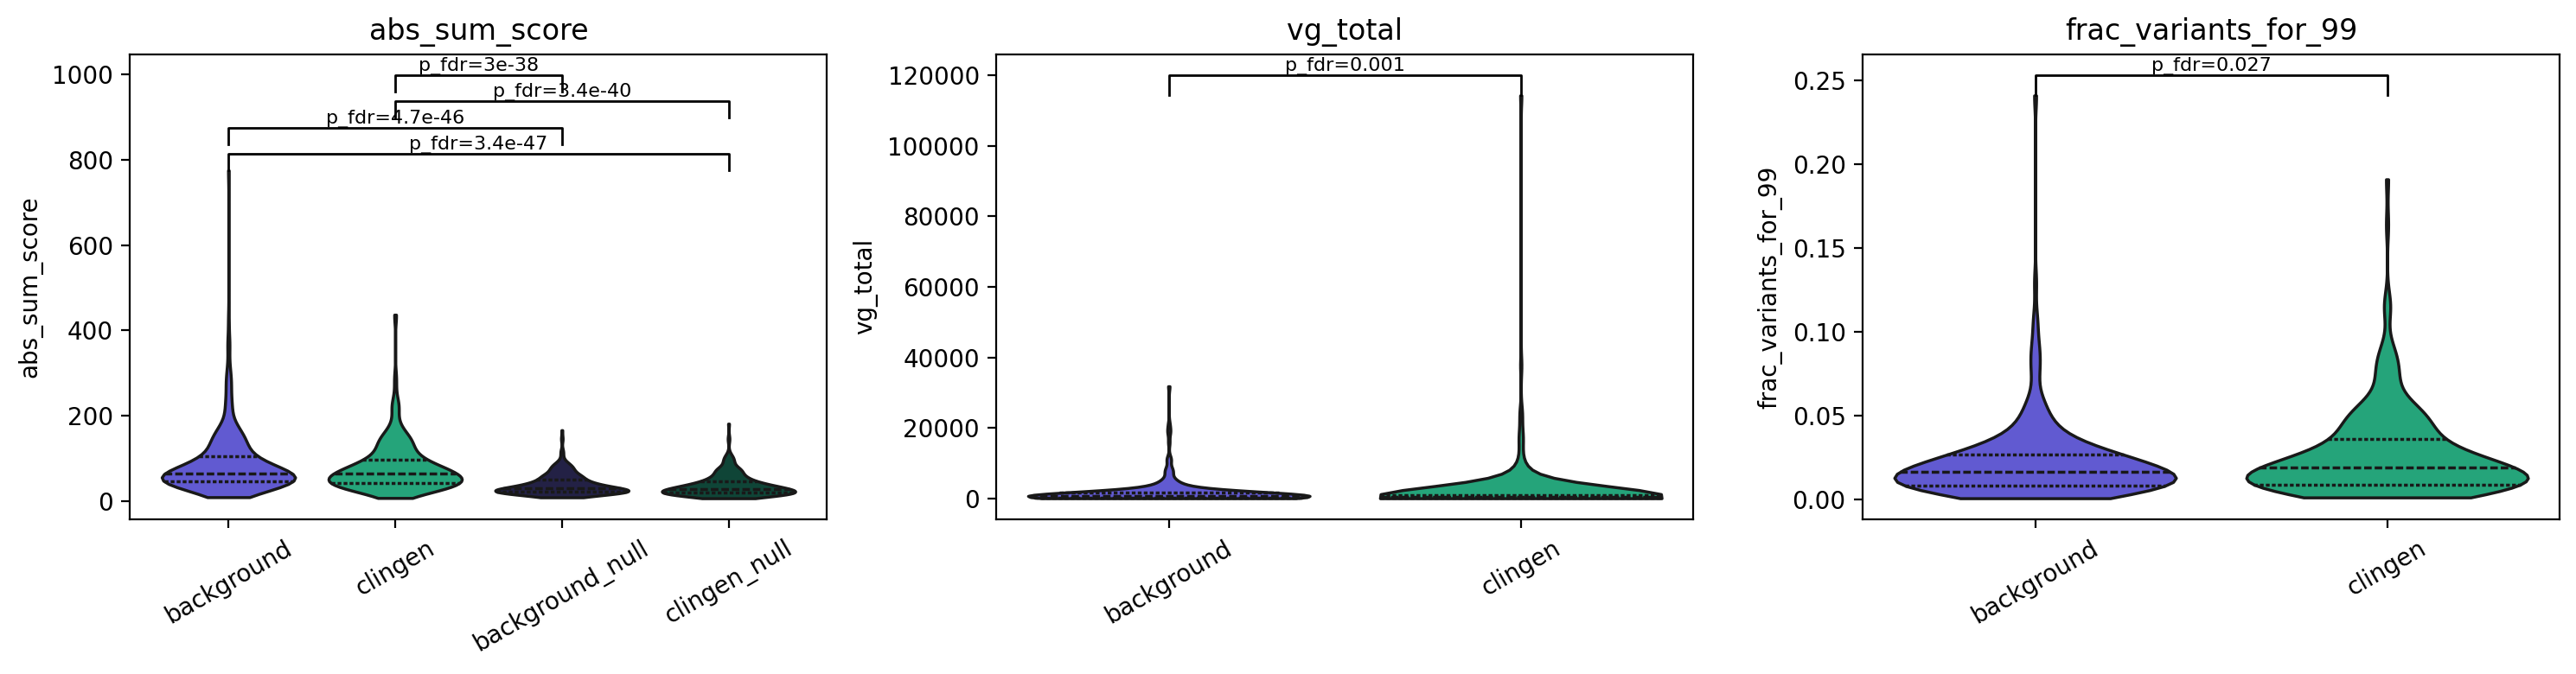

In [70]:
def _annotate_pairwise(
    ax: plt.Axes,
    stats_df: pd.DataFrame,
    order: list[str],
    y_max: float,
    y_step: float,
    label_fmt: str = 'p_fdr={p:.2g}',
) -> None:
    """annotate pairwise stats on a single axis.

    args:
        ax (plt.Axes): target axis.
        stats_df (pd.DataFrame): pairwise stats with group_a, group_b, p_fdr.
        order (list[str]): x-axis order.
        y_max (float): start y position.
        y_step (float): vertical spacing.
        label_fmt (str): label format.

    returns:
        None
    """
    if stats_df.empty:
        return

    pair_stats = stats_df.copy()
    pair_stats = pair_stats.sort_values('p_fdr')
    current_y = y_max

    for _, row in pair_stats.iterrows():
        if row['group_a'] not in order or row['group_b'] not in order:
            continue
        if row['p_fdr'] >= 0.05:
            continue

        x1 = order.index(row['group_a'])
        x2 = order.index(row['group_b'])
        if x1 == x2:
            continue

        x_low, x_high = sorted([x1, x2])
        ax.plot([x_low, x_low, x_high, x_high], [current_y, current_y + y_step, current_y + y_step, current_y], color='black', linewidth=1)
        label = label_fmt.format(p=row['p_fdr'])
        ax.text(
            (x_low + x_high) / 2,
            current_y + y_step,
            label,
            ha='center',
            va='bottom',
            fontsize=8,
        )
        current_y += y_step * 1.6


def plot_key_violin_panels(
    df: pd.DataFrame,
    metrics: list[str],
    order: list[str],
) -> None:
    """plot key violins with dataset comparisons and annotations.

    args:
        df (pd.DataFrame): gene-level metrics with dataset column.
        metrics (list[str]): metrics to plot.
        order (list[str]): dataset order.

    returns:
        None
    """
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4), dpi=200)
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        sns.violinplot(
            data=df,
            x='dataset',
            y=metric,
            order=order,
            cut=0,
            inner='quartile',
            palette=SOURCE_PALETTE,
            ax=ax,
        )

        ax.set_title(metric)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)

        stats_df = _mw_pairwise(df, 'dataset', metric)
        y_vals = df[metric].replace([np.inf, -np.inf], np.nan).dropna()
        if y_vals.empty:
            continue
        y_max = float(y_vals.max())
        y_step = float((y_vals.max() - y_vals.min()) * 0.05) or 1.0

        _annotate_pairwise(ax, stats_df, order, y_max, y_step)

    plt.tight_layout()
    plt.show()


key_metrics = ['abs_sum_score', 'vg_total', 'frac_variants_for_99']
plot_key_violin_panels(
    gene_metrics_df,
    metrics=key_metrics,
    order=['background', 'clingen', 'background_null', 'clingen_null'],
)
